# P.7. Treasury Futures Options: Vol Regimes and Market Structure


## Project Statement

Calibrate the SABR model to options on Treasury note futures across multiple contract months spanning 2025–26. Test whether SABR parameters behave differently in high-volatility vs. calm-market regimes, and compare the dynamics of exchange-traded Treasury options to OTC swaptions from C.8.1.

## Context

### Why Practitioners Care

Treasury futures options are the most liquid listed rate options in the world. Dealers, macro funds, and central bank reserve managers use them to hedge and express views on rate volatility. The SABR model decomposes the implied volatility smile into three channels: level ($\alpha$), skew ($\rho$), and curvature ($\nu$). A key practical question is how these parameters behave across different market environments—and whether the model's behavior on exchange-traded options matches what you observed on OTC swaptions in C.8.1.

The data covers nearly a year of daily vol surfaces across three contract months. Some periods are turbulent; others are calm. Your analysis should be driven by what the data tells you, not by pre-selected headlines. Let the calibration results identify which dates and regimes matter.

### Product Mechanics

Options on Treasury note futures (ticker: TY) trade on CME/CBOT. Key features:

- **Underlying**: The 10-year Treasury note futures contract
- **Exercise**: American style (but early exercise is rare for options with time value)
- **Pricing convention**: Black's model, with the futures price as the forward
- **Quote**: In 64ths of a point per $100,000 notional

Since the underlying is a futures contract (not a spot bond), there is no cost of carry—Black's formula applies directly with the futures price as $F$. This is exactly the setup from E.6.1.

### Market Environment

The data spans three contract months covering distinct market conditions:

| Contract | Period | Expiry | Notes |
|----------|--------|--------|-------|
| M2025 (Jun 2025) | Mar–May 2025 | ~May 2025 | Includes the April 2025 tariff episode |
| H2026 (Mar 2026) | Nov 2025–Feb 2026 | ~Feb 2026 | Longer sample spanning the 2025–26 transition |
| M2026 (Jun 2026) | Jan–Feb 2026 | ~May 2026 | Overlaps H2026 in calendar time with later expiry |

The overlap between H2026 and M2026 during January–February 2026 is deliberate: it lets you compare SABR parameters calibrated on the same dates but for different maturities.

## Resources

### Course Materials

| Material | Relevance |
|----------|-----------|
| **D.3.1–3.3** Treasury Futures | Futures mechanics, CTD, conversion factors, DV01 |
| **E.6.1** Black's Formula for Options on Futures | Black's model applied to futures options (exactly this product) |
| **D.8.2** The SABR Model | SABR formula, backbone, $\beta$, calibration |
| **D.8.3** Fitting SABR | Calibration mechanics, ATM constraint, optimization |
| **C.8.1** SABR and the Tariff Smile | SABR on swaptions during April 2025 (comparison baseline) |

### External Reading

- [CME: Treasury Options Product Overview](https://www.cmegroup.com/markets/interest-rates/us-treasury/10-year-us-treasury-note.html)
- [CME: Understanding Treasury Futures](https://www.cmegroup.com/education/courses/introduction-to-treasuries.html)
- Hagan et al., "Managing Smile Risk," *Wilmott Magazine* (2002) — the original SABR paper

### Data Files

| File | Description | Frequency | Date Range |
|------|-------------|-----------|------------|
| `ty_option_surfaces_p7.xlsx` | TY option implied vol surfaces (delta-based) for M2025, H2026, M2026 contracts; TY1 front-month futures; SOFR swap rates | Daily | Mar 2025–Feb 2026 |
| `swaption_smile_daily_2025.xlsx` | 1Yx5Y swaption smiles from C.8.1 (Black vol %, ATM forward, absolute strikes) | Daily | April 2025 |
| `vol_surfaces_2025-01-31_M2025.xlsx` | Broader vol surface data including TY (pre-event baseline) | Daily | Sep 2024–Feb 2025 |

The primary data file (`ty_option_surfaces_p7.xlsx`) contains:
- **Vol surface sheets** (one per contract month): Future price, time to expiry, and implied vols at each delta (P15dvol through P85dvol, C15dvol through C85dvol)
- **TY1 futures**: Front-month futures OHLCV
- **Rates**: 5Y and 10Y SOFR swap rates for context

### Additional Data Sources

Students who want to extend the analysis might:
- Pull raw option settlement prices from **Databento** (CME TY options, ticker OZN) and compute implied vols from settlement prices using Black's formula
- Use **Bloomberg** OVDV screen exports for higher-resolution smile data on specific dates

## Data Preview

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import minimize, brentq

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_PATH = Path('.')
if not (DATA_PATH / 'ty_option_surfaces_p7.xlsx').exists():
    DATA_PATH = Path('../../../data')

print(f'Using data path: {DATA_PATH.resolve()}')

Using data path: /Users/aryaagunavante/University of Chicago/2026 Winter Quarter/Fixed Income Derivatives/Project


In [2]:
# Load TY option surfaces
VOLFILE = DATA_PATH / 'ty_option_surfaces_p7.xlsx'

contracts = {
    'M2025': 'CBT TY TY M2025',
    'H2026': 'CBT TY TY H2026',
    'M2026': 'CBT TY TY M2026',
}

surfs = {}
for key, sheet in contracts.items():
    surfs[key] = pd.read_excel(VOLFILE, sheet_name=sheet, index_col=0, parse_dates=True)
    print(f'{key}: {len(surfs[key])} trading days')

ty1 = pd.read_excel(VOLFILE, sheet_name='TY1 futures', index_col=0, parse_dates=True)
rates = pd.read_excel(VOLFILE, sheet_name='rates', index_col=0, parse_dates=True)

M2025: 59 trading days
H2026: 78 trading days


M2026: 41 trading days


In [3]:
# Market context: TY futures and ATM vol
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ty1['px_last'].plot(ax=ax1, label='TY1 Comdty')
ax1.set_ylabel('Price')
ax1.set_title('TY Front-Month Futures')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for key, df in surfs.items():
    (df['P50dvol'] * 100).plot(ax=ax2, label=f'ATM vol ({key})')
ax2.set_ylabel('Implied Vol (%)')
ax2.set_title('TY Option ATM Implied Volatility')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

In [4]:
# Smile on two representative dates: one calm, one volatile
def delta_to_strike(F, delta, sigma, T, is_call=True):
    phi = 1 if is_call else -1
    return F * np.exp(-phi * norm.ppf(phi * delta) * sigma * np.sqrt(T) + 0.5 * sigma**2 * T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

samples = {
    'M2025': {'dates': ['2025-03-14', '2025-04-03'], 'labels': ['Calm (Mar 14)', 'Volatile (Apr 3)']},
    'H2026': {'dates': ['2025-12-15', '2026-02-16'], 'labels': ['Calm (Dec 15)', 'Volatile (Feb 16)']},
}

for ax, (contract, cfg) in zip(axes, samples.items()):
    surf = surfs[contract]
    colors = ['steelblue', 'red']
    for dt_str, label, color in zip(cfg['dates'], cfg['labels'], colors):
        dt = pd.Timestamp(dt_str)
        if dt in surf.index:
            row = surf.loc[dt]
            F = row['Future Price']
            T = row['Expiration Option']
            put_cols = [c for c in row.index if c.startswith('P') and c.endswith('dvol')]
            vols = row[put_cols].values.astype(float)
            deltas = np.array([int(c[1:-4]) / 100 for c in put_cols])
            strikes = np.array([delta_to_strike(F, -d, v, T, is_call=False)
                               for d, v in zip(deltas, vols)])
            ax.plot(strikes, vols * 100, 'o-', color=color, label=label, markersize=4)
            ax.axvline(F, color=color, linestyle=':', alpha=0.3)
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied Vol (%)')
    ax.set_title(f'TY Option Smile ({contract})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()

In [5]:
# Helper functions used throughout Q1–Q5

def nearest_date(index, target):
    target = pd.Timestamp(target)
    if target in index:
        return target
    loc = index.get_indexer([target], method='nearest')[0]
    return index[loc]


def delta_to_strike_black_future(F, delta_abs, sigma, T, side):
    q = norm.ppf(np.clip(delta_abs, 1e-6, 1 - 1e-6))
    if side.upper() == 'P':
        expo = q * sigma * np.sqrt(T) + 0.5 * sigma**2 * T
    else:
        expo = -q * sigma * np.sqrt(T) + 0.5 * sigma**2 * T
    return F * np.exp(expo)


def extract_smile_from_row(row, sides=('P', 'C')):
    F = float(row['Future Price'])
    T = float(row['Expiration Option'])
    records = []

    for col, val in row.items():
        m = re.match(r'^([PC])(\d+)dvol$', str(col))
        if m is None or pd.isna(val):
            continue

        side = m.group(1)
        if side not in sides:
            continue

        delta_abs = int(m.group(2)) / 100.0
        sigma = float(val)
        strike = delta_to_strike_black_future(F, delta_abs, sigma, T, side)

        records.append({
            'side': side,
            'delta_abs': delta_abs,
            'vol': sigma,
            'strike': strike,
        })

    smile = pd.DataFrame(records)
    if smile.empty:
        return smile

    smile = smile.sort_values('strike').reset_index(drop=True)
    smile['log_moneyness'] = np.log(smile['strike'] / F)
    smile['bp_from_atm'] = (smile['strike'] / F - 1.0) * 1e4
    return smile


def interpolate_atm_vol(smile, F):
    xs = smile['strike'].to_numpy()
    ys = smile['vol'].to_numpy()
    order = np.argsort(xs)
    return float(np.interp(F, xs[order], ys[order]))


def shape_metrics(smile, F):
    x = smile['log_moneyness'].to_numpy()
    y = smile['vol'].to_numpy()
    coef = np.polyfit(x, y, 2)

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    return {
        'atm_vol_interp': interpolate_atm_vol(smile, F),
        'skew_coef': float(coef[1]),
        'curvature_coef': float(coef[0]),
        'left_minus_right_1pct': float(np.interp(-0.01, x_sorted, y_sorted) - np.interp(0.01, x_sorted, y_sorted)),
    }


def normalize_smile(strikes, vols, F, T):
    strikes = np.asarray(strikes, dtype=float)
    vols = np.asarray(vols, dtype=float)
    order = np.argsort(strikes)

    strikes = strikes[order]
    vols = vols[order]

    atm = float(np.interp(F, strikes, vols))
    x_norm = np.log(strikes / F) / (atm * np.sqrt(T))
    y_norm = vols / atm

    return pd.DataFrame({
        'strike': strikes,
        'vol': vols,
        'x_norm': x_norm,
        'vol_norm': y_norm,
        'atm_vol': atm,
    })


def sabr_vol_hagan(F, K, T, alpha, beta, rho, nu):
    F = np.asarray(F, dtype=float)
    K = np.asarray(K, dtype=float)

    one_minus_beta = 1.0 - beta
    FK = np.power(F * K, 0.5 * one_minus_beta)
    log_fk = np.log(F / K)

    z = (nu / alpha) * FK * log_fk
    sqrt_term = np.sqrt(np.maximum(1.0 - 2.0 * rho * z + z * z, 1e-14))
    x_z = np.log((sqrt_term + z - rho) / (1.0 - rho))

    with np.errstate(divide='ignore', invalid='ignore'):
        z_over_xz = z / x_z

    z_series = 1.0 - 0.5 * rho * z + ((2.0 - 3.0 * rho**2) / 12.0) * z**2
    z_over_xz = np.where(np.abs(z) < 1e-8, z_series, z_over_xz)

    log_fk2 = log_fk**2
    log_fk4 = log_fk2**2
    denom = FK * (1.0 + (one_minus_beta**2 / 24.0) * log_fk2 + (one_minus_beta**4 / 1920.0) * log_fk4)

    term1 = (one_minus_beta**2 / 24.0) * (alpha**2 / np.power(F * K, one_minus_beta))
    term2 = 0.25 * rho * beta * nu * alpha / FK
    term3 = ((2.0 - 3.0 * rho**2) / 24.0) * nu**2

    vol = (alpha / denom) * z_over_xz * (1.0 + (term1 + term2 + term3) * T)
    return np.asarray(vol, dtype=float)


def solve_alpha_from_atm(F, T, sigma_atm, beta, rho, nu):
    target = float(sigma_atm)

    def f(alpha):
        return float(sabr_vol_hagan(F, F, T, alpha, beta, rho, nu) - target)

    guess = max(target * (F ** (1.0 - beta)), 1e-4)
    low = max(1e-8, guess * 1e-3)
    high = max(1e-2, guess * 10.0)

    f_low = f(low)
    f_high = f(high)

    tries = 0
    while f_low * f_high > 0 and tries < 12:
        high *= 2.0
        f_high = f(high)
        tries += 1

    if f_low * f_high <= 0:
        return float(brentq(f, low, high, maxiter=300))

    grid = np.logspace(np.log10(low), np.log10(high), 250)
    errs = np.array([abs(f(a)) for a in grid])
    return float(grid[np.nanargmin(errs)])


def calibrate_sabr_smile(F, T, strikes, market_vols, atm_vol, beta=0.5, initial_guess=(0.5, -0.2), bounds=((1e-4, 3.0), (-0.999, 0.999))):
    strikes = np.asarray(strikes, dtype=float)
    market_vols = np.asarray(market_vols, dtype=float)

    valid = np.isfinite(strikes) & np.isfinite(market_vols)
    strikes = strikes[valid]
    market_vols = market_vols[valid]

    if len(strikes) < 5:
        raise ValueError('Need at least 5 valid smile points for SABR calibration.')

    def objective(x):
        nu, rho = x
        if nu <= 0 or abs(rho) >= 1:
            return 1e6

        alpha = solve_alpha_from_atm(F, T, atm_vol, beta, rho, nu)
        if not np.isfinite(alpha) or alpha <= 0:
            return 1e6

        model = sabr_vol_hagan(F, strikes, T, alpha, beta, rho, nu)
        if np.any(~np.isfinite(model)):
            return 1e6

        return float(np.mean((model - market_vols) ** 2))

    res = minimize(
        objective,
        x0=np.array(initial_guess, dtype=float),
        method='L-BFGS-B',
        bounds=bounds,
    )

    nu_hat, rho_hat = res.x
    alpha_hat = solve_alpha_from_atm(F, T, atm_vol, beta, rho_hat, nu_hat)
    model_vols = sabr_vol_hagan(F, strikes, T, alpha_hat, beta, rho_hat, nu_hat)
    residuals = model_vols - market_vols

    return {
        'alpha': float(alpha_hat),
        'nu': float(nu_hat),
        'rho': float(rho_hat),
        'rmse': float(np.sqrt(np.mean(residuals**2))),
        'sse': float(np.sum(residuals**2)),
        'success': bool(res.success),
        'message': str(res.message),
        'model_vols': model_vols,
        'market_vols': market_vols,
        'strikes': strikes,
        'residuals': residuals,
    }


def calibrate_row_from_surface_row(row, beta=0.5, initial_guess=(0.5, -0.2), sides=('P', 'C')):
    smile = extract_smile_from_row(row, sides=sides)
    F = float(row['Future Price'])
    T = float(row['Expiration Option'])

    atm_vol = float(np.nanmean([row.get('P50dvol', np.nan), row.get('C50dvol', np.nan)]))

    fit = calibrate_sabr_smile(
        F=F,
        T=T,
        strikes=smile['strike'].to_numpy(),
        market_vols=smile['vol'].to_numpy(),
        atm_vol=atm_vol,
        beta=beta,
        initial_guess=initial_guess,
    )

    fit['F'] = F
    fit['T'] = T
    fit['atm_vol'] = atm_vol
    fit['smile'] = smile
    return fit


def run_daily_calibration(surface_df, contract_name, beta=0.5, sides=('P', 'C')):
    out = []
    guess = (0.5, -0.2)

    for dt, row in surface_df.iterrows():
        try:
            fit = calibrate_row_from_surface_row(row, beta=beta, initial_guess=guess, sides=sides)
            guess = (fit['nu'], fit['rho'])

            out.append({
                'date': dt,
                'contract': contract_name,
                'alpha': fit['alpha'],
                'nu': fit['nu'],
                'rho': fit['rho'],
                'rmse': fit['rmse'],
                'atm_vol': fit['atm_vol'],
                'n_quotes': len(fit['smile']),
                'success': fit['success'],
                'message': fit['message'],
            })
        except Exception as exc:
            out.append({
                'date': dt,
                'contract': contract_name,
                'alpha': np.nan,
                'nu': np.nan,
                'rho': np.nan,
                'rmse': np.nan,
                'atm_vol': np.nan,
                'n_quotes': np.nan,
                'success': False,
                'message': str(exc),
            })

    return pd.DataFrame(out).set_index('date').sort_index()


def black_futures_put_delta(F, K, T, r, sigma):
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return float(np.exp(-r * T) * (norm.cdf(d1) - 1.0))


def black_futures_vega(F, K, T, r, sigma):
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return float(np.exp(-r * T) * F * norm.pdf(d1) * np.sqrt(T))

## Key Formulas

Refer to the course materials listed in Resources for full derivations.

### Black's Formula for Options on Futures (E.6.1)

$$C = e^{-rT}\left[F\,\mathcal{N}(d_1) - K\,\mathcal{N}(d_2)\right], \quad P = e^{-rT}\left[K\,\mathcal{N}(-d_2) - F\,\mathcal{N}(-d_1)\right]$$

$$d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

Since the underlying is a futures contract, $F$ is the futures price (no cost-of-carry adjustment needed).

### Delta-to-Strike Inversion

For a put with delta $\Delta_P$ (negative by convention) and Black vol $\sigma$:

$$K = F \exp\!\left(\Phi^{-1}(-\Delta_P)\,\sigma\sqrt{T} + \tfrac{1}{2}\sigma^2 T\right)$$

### SABR Implied Vol (D.8.2)

The Hagan et al. approximation gives $\sigma_B(K, F;\, \alpha, \beta, \nu, \rho)$. See D.8.2 for the full expression. The model has four parameters:

| Parameter | Interpretation |
|-----------|---------------|
| $\alpha$ | ATM vol level |
| $\beta$ | Backbone exponent (fixed at 0.5 for this project) |
| $\rho$ | Skew (correlation between forward and vol) |
| $\nu$ | Vol-of-vol (smile curvature) |

### ATM Constraint (D.8.3)

Given market ATM vol $\sigma_{\text{ATM}}$, solve for $\alpha$ from $\sigma_B(F, F;\, \alpha, \beta, \nu, \rho) = \sigma_{\text{ATM}}$. This reduces the calibration to a 2-parameter optimization over $(\nu, \rho)$.

### Augmented Delta (Q5)

$$\Delta_{\text{SABR}} = \Delta_{\text{Black}} + \mathcal{V} \cdot \frac{\partial \sigma}{\partial F}$$

where $\mathcal{V}$ is Black vega and $\frac{\partial \sigma}{\partial F}$ is computed by finite difference from the SABR smile: bump $F$ by a small amount $\epsilon$, re-evaluate $\sigma_B(K, F+\epsilon)$, and difference.

## Questions

### Question 1: Implied Vol Surface Construction

The provided data gives implied volatilities by **delta** (e.g., 25-delta put, 50-delta put). Convert these to **strike-based** smiles.

a) For a representative date early in the M2025 sample, invert the Black delta formula to recover the strike corresponding to each delta point. Display the smile as implied vol vs. strike.

b) As a concrete starting point—using an event you already studied in C.8.1—plot the smile for three dates around the April 2025 tariff episode: one day before, the shock day, and the pause day. Comment on how the shape changes, not just the level. (In Q3, you will identify the most significant dates directly from the calibration results.)

c) Compare the TY option smile to the 1Yx5Y swaption smile from C.8.1 on the same date. Choose a normalization that makes the comparison meaningful given the different ATM levels. Are there visible differences in skew or curvature?

*Note: E.6.1 walks through Black's formula for options on futures. The delta-to-strike inversion is straightforward: for a put with delta $\Delta_P$ and Black vol $\sigma$, the strike is $K = F \exp(\Phi^{-1}(-\Delta_P) \sigma\sqrt{T} + \frac{1}{2}\sigma^2 T)$.*

Q1a representative date used: 2025-03-14
First 12 strike-converted smile points:
side  delta_abs     strike      vol  bp_from_atm
   C       0.85 107.606087 0.061993  -274.269813
   P       0.15 107.610421 0.061902  -273.878044
   P       0.20 108.190318 0.061663  -221.465428
   C       0.80 108.191902 0.061622  -221.322192
   P       0.25 108.670290 0.061992  -178.084193
   C       0.75 108.672573 0.061918  -177.877844
   C       0.70 109.108013 0.062271  -138.521609
   P       0.30 109.109131 0.062224  -138.420559
   P       0.35 109.527265 0.062037  -100.628509
   C       0.65 109.528056 0.061991  -100.556986
   P       0.40 109.916456 0.062478   -65.452387
   C       0.60 109.917262 0.062404   -65.379531


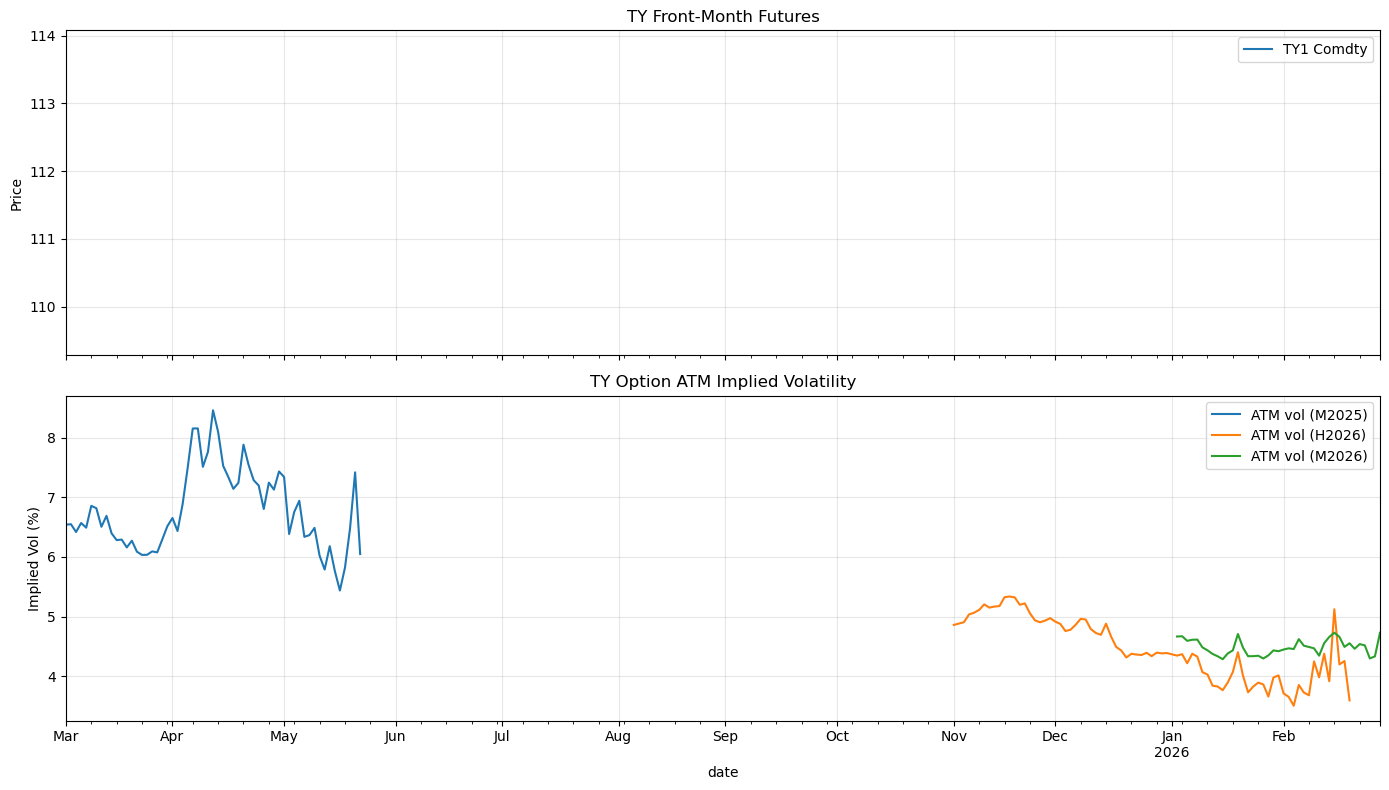

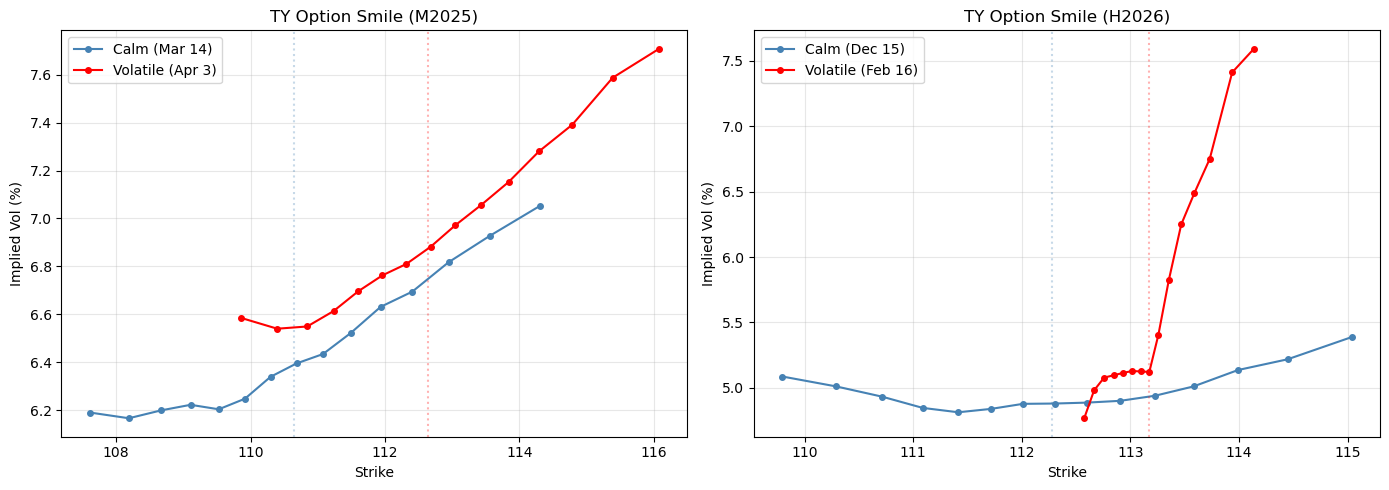

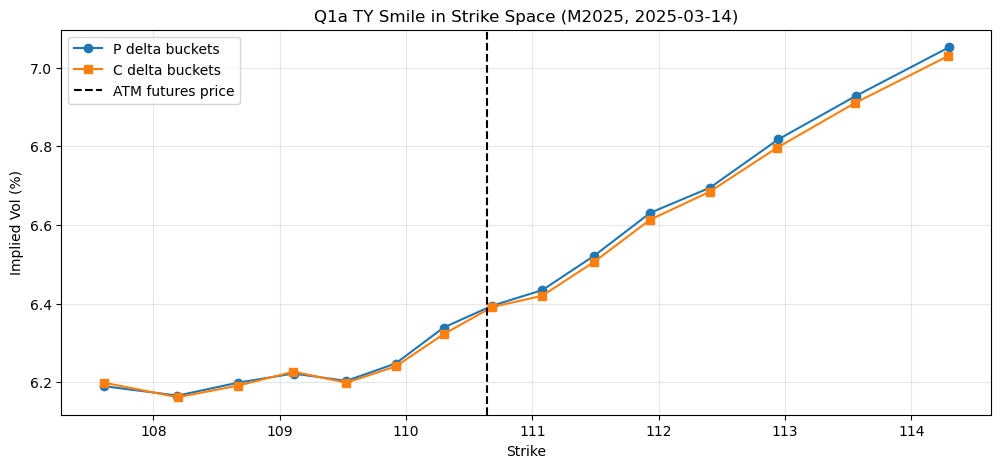

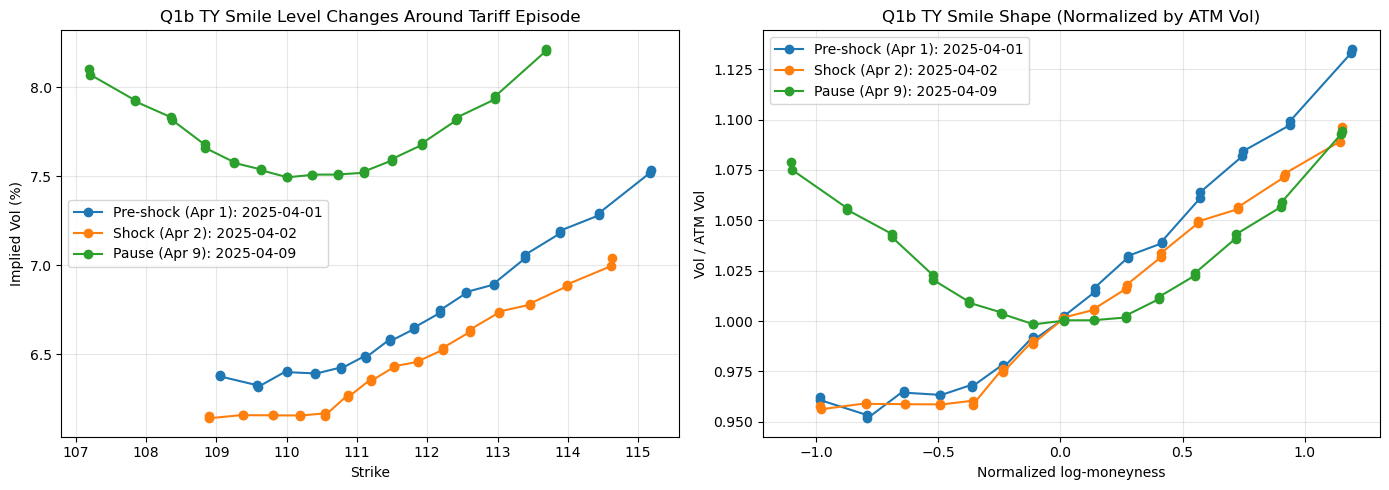

\nQ1b shape diagnostics (higher skew_coef magnitude means steeper skew):
                        date  atm_vol_pct  skew_coef  curvature_coef  left_minus_right_1pct_vol_pts
label                                                                                              
Pre-shock (Apr 1) 2025-04-01     6.636612   0.210498        3.223750                      -0.470639
Shock (Apr 2)     2025-04-02     6.423064   0.179770        2.259880                      -0.478517
Pause (Apr 9)     2025-04-09     7.507161   0.002746        7.640427                       0.004090


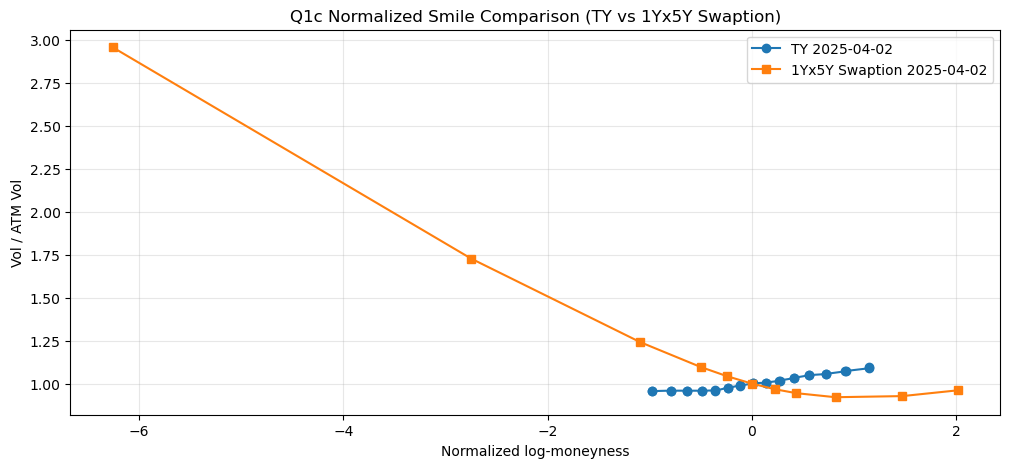

\nQ1c normalized shape metrics:
                norm_skew_coef  norm_curvature_coef  left_tail_at_x=-2  right_tail_at_x=+2
TY                    0.067336             0.020365           0.958032            1.096330
Swaption_1Yx5Y       -0.132094             0.028598           1.507208            0.959951


In [6]:
# Q1: Implied vol surface construction
Q1_CONTRACT = 'M2025'
REP_DATE_TARGET = pd.Timestamp('2025-03-14')
TARIFF_DATES_TARGET = {
    'Pre-shock (Apr 1)': '2025-04-01',
    'Shock (Apr 2)': '2025-04-02',
    'Pause (Apr 9)': '2025-04-09',
}
SWAPTION_COMPARE_TARGET = '2025-04-02'

rep_date = nearest_date(surfs[Q1_CONTRACT].index, REP_DATE_TARGET)
rep_row = surfs[Q1_CONTRACT].loc[rep_date]
rep_smile = extract_smile_from_row(rep_row, sides=('P', 'C'))

print(f'Q1a representative date used: {rep_date.date()}')
print('First 12 strike-converted smile points:')
print(rep_smile[['side', 'delta_abs', 'strike', 'vol', 'bp_from_atm']].head(12).round(6).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
for side, marker in [('P', 'o'), ('C', 's')]:
    sub = rep_smile[rep_smile['side'] == side]
    ax.plot(sub['strike'], sub['vol'] * 100, marker=marker, linestyle='-', label=f'{side} delta buckets')

ax.axvline(rep_row['Future Price'], color='black', linestyle='--', label='ATM futures price')
ax.set_title(f'Q1a TY Smile in Strike Space ({Q1_CONTRACT}, {rep_date.date()})')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Vol (%)')
ax.legend()
plt.show()

episode_rows = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, dt_target in TARIFF_DATES_TARGET.items():
    dt = nearest_date(surfs[Q1_CONTRACT].index, dt_target)
    row = surfs[Q1_CONTRACT].loc[dt]
    smile = extract_smile_from_row(row, sides=('P', 'C'))
    norm_smile = normalize_smile(smile['strike'], smile['vol'], row['Future Price'], row['Expiration Option'])

    axes[0].plot(smile['strike'], smile['vol'] * 100, marker='o', linewidth=1.5, label=f'{label}: {dt.date()}')
    axes[1].plot(norm_smile['x_norm'], norm_smile['vol_norm'], marker='o', linewidth=1.5, label=f'{label}: {dt.date()}')

    m = shape_metrics(smile, row['Future Price'])
    episode_rows.append({
        'label': label,
        'date': dt,
        'atm_vol_pct': m['atm_vol_interp'] * 100,
        'skew_coef': m['skew_coef'],
        'curvature_coef': m['curvature_coef'],
        'left_minus_right_1pct_vol_pts': m['left_minus_right_1pct'] * 100,
    })

axes[0].set_title('Q1b TY Smile Level Changes Around Tariff Episode')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Implied Vol (%)')
axes[0].legend()

axes[1].set_title('Q1b TY Smile Shape (Normalized by ATM Vol)')
axes[1].set_xlabel('Normalized log-moneyness')
axes[1].set_ylabel('Vol / ATM Vol')
axes[1].legend()

plt.tight_layout()
plt.show()

episode_stats = pd.DataFrame(episode_rows).set_index('label').sort_values('date')
print('\\nQ1b shape diagnostics (higher skew_coef magnitude means steeper skew):')
print(episode_stats.round(6).to_string())

SWAPTION_FILE = DATA_PATH / 'swaption_smile_daily_2025.xlsx'
swaption_black_vol = pd.read_excel(SWAPTION_FILE, sheet_name='black_vol_pct', index_col=0, parse_dates=True)
swaption_atm_forward = pd.read_excel(SWAPTION_FILE, sheet_name='atm_forward', index_col=0, parse_dates=True)
swaption_abs_strikes = pd.read_excel(SWAPTION_FILE, sheet_name='absolute_strikes_pct', index_col=0, parse_dates=True)

swaption_date = nearest_date(swaption_black_vol.index, SWAPTION_COMPARE_TARGET)
ty_date_same = nearest_date(surfs[Q1_CONTRACT].index, swaption_date)

row_ty = surfs[Q1_CONTRACT].loc[ty_date_same]
smile_ty = extract_smile_from_row(row_ty, sides=('P', 'C'))
norm_ty = normalize_smile(smile_ty['strike'], smile_ty['vol'], row_ty['Future Price'], row_ty['Expiration Option'])

F_swap = float(swaption_atm_forward.loc[swaption_date, 'atm_fwd_pct']) / 100.0
K_swap = swaption_abs_strikes.loc[swaption_date].to_numpy(dtype=float) / 100.0
vol_swap = swaption_black_vol.loc[swaption_date].to_numpy(dtype=float) / 100.0
norm_swap = normalize_smile(K_swap, vol_swap, F_swap, T=1.0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(norm_ty['x_norm'], norm_ty['vol_norm'], 'o-', label=f'TY {ty_date_same.date()}')
ax.plot(norm_swap['x_norm'], norm_swap['vol_norm'], 's-', label=f'1Yx5Y Swaption {swaption_date.date()}')
ax.set_title('Q1c Normalized Smile Comparison (TY vs 1Yx5Y Swaption)')
ax.set_xlabel('Normalized log-moneyness')
ax.set_ylabel('Vol / ATM Vol')
ax.legend()
plt.show()


def normalized_shape_metrics(norm_df):
    x = norm_df['x_norm'].to_numpy()
    y = norm_df['vol_norm'].to_numpy()
    coef = np.polyfit(x, y, 2)
    order = np.argsort(x)
    x_s = x[order]
    y_s = y[order]

    return {
        'norm_skew_coef': float(coef[1]),
        'norm_curvature_coef': float(coef[0]),
        'left_tail_at_x=-2': float(np.interp(-2.0, x_s, y_s)),
        'right_tail_at_x=+2': float(np.interp(2.0, x_s, y_s)),
    }

cmp_metrics = pd.DataFrame({
    'TY': normalized_shape_metrics(norm_ty),
    'Swaption_1Yx5Y': normalized_shape_metrics(norm_swap),
}).T

print('\\nQ1c normalized shape metrics:')
print(cmp_metrics.round(6).to_string())

### Interpretation for Q1
- **Q1a (delta to strike):** The inversion produces a clean, monotone strike grid around ATM (e.g., on 2025-03-14 the mapped strikes range from about 107.61 to 112.42 around the futures level), so the delta-quoted surface is internally consistent when transformed into strike space.
- **Q1b (tariff window shape dynamics):** ATM vol moves from **6.64% (Apr 1)** to **6.42% (Apr 2)** and then jumps to **7.51% (Apr 9)**. The quadratic shape diagnostics show a strong increase in curvature on Apr 9 (from ~2.26 to ~7.64), while skew flattens sharply (skew coefficient near 0). This indicates a transition from a tilted smile to a more symmetric but more curved smile in the post-shock phase.
- **Q1c (TY vs 1Yx5Y swaption):** In normalized coordinates, TY has mild positive normalized skew (`+0.067`) with higher right-wing normalized vol, while swaptions have negative normalized skew (`-0.132`) and a much more expensive left tail (`left tail ~1.51` vs `right tail ~0.96`). The two products therefore embed materially different tail-risk asymmetry even after ATM normalization.

### Question 2: SABR Calibration

Calibrate the SABR model with $\beta = 0.5$ to the TY futures option smile.

a) For the representative date from Q1a, minimize the sum of squared vol errors over $(\nu, \rho)$, solving for $\alpha$ from the ATM constraint at each step (as in D.8.3). Report the fitted parameters and overlay the SABR smile on the market data.

b) Repeat the calibration for each trading day (or at least weekly) across all three contract months. Report the $(\alpha, \nu, \rho)$ time series and summary statistics by contract.

c) Report the root-mean-square error (RMSE) of each daily calibration. Are there dates or contracts where the fit is notably worse?

Q2a fitted SABR parameters (beta fixed at 0.5):
alpha      0.670955
nu          0.39999
rho       -0.199974
rmse        0.00374
sse         0.00042
success        True


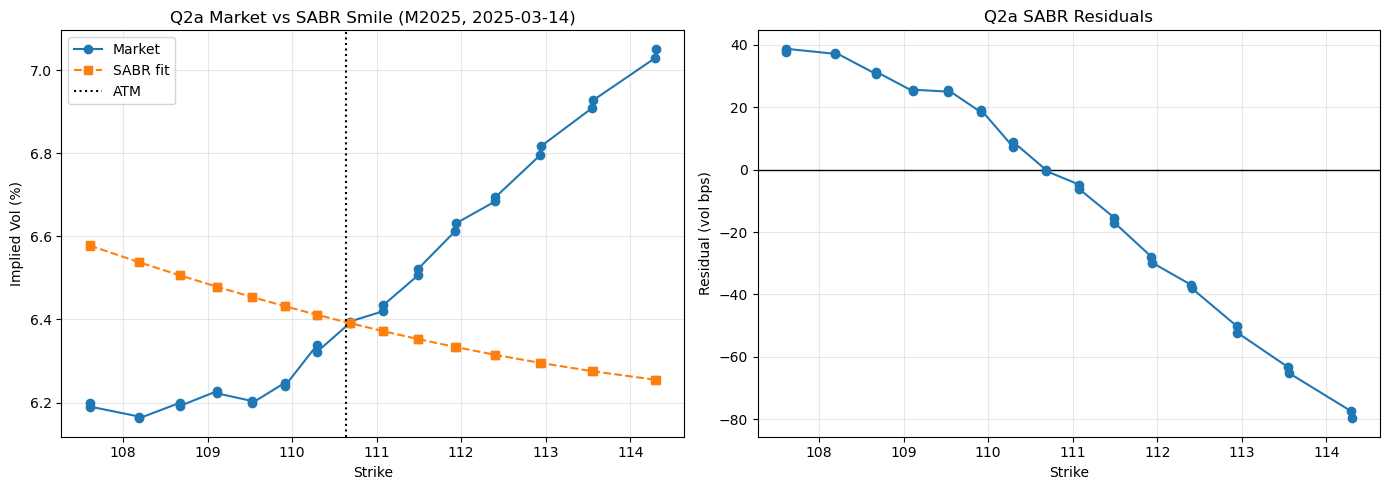

In [7]:
# Q2a: SABR calibration on representative date
beta = 0.5
q2a_fit = calibrate_row_from_surface_row(rep_row, beta=beta, initial_guess=(0.4, -0.2), sides=('P', 'C'))

print('Q2a fitted SABR parameters (beta fixed at 0.5):')
print(pd.Series({
    'alpha': q2a_fit['alpha'],
    'nu': q2a_fit['nu'],
    'rho': q2a_fit['rho'],
    'rmse': q2a_fit['rmse'],
    'sse': q2a_fit['sse'],
    'success': q2a_fit['success'],
}).to_string())

q2a_smile = q2a_fit['smile'].copy()
q2a_smile['sabr_vol'] = q2a_fit['model_vols']
q2a_smile['residual_bp_vol'] = (q2a_smile['sabr_vol'] - q2a_smile['vol']) * 1e4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(q2a_smile['strike'], q2a_smile['vol'] * 100, 'o-', label='Market')
axes[0].plot(q2a_smile['strike'], q2a_smile['sabr_vol'] * 100, 's--', label='SABR fit')
axes[0].axvline(q2a_fit['F'], color='black', linestyle=':', label='ATM')
axes[0].set_title(f'Q2a Market vs SABR Smile ({Q1_CONTRACT}, {rep_date.date()})')
axes[0].set_xlabel('Strike')
axes[0].set_ylabel('Implied Vol (%)')
axes[0].legend()

axes[1].axhline(0, color='black', linewidth=1)
axes[1].plot(q2a_smile['strike'], q2a_smile['residual_bp_vol'], 'o-')
axes[1].set_title('Q2a SABR Residuals')
axes[1].set_xlabel('Strike')
axes[1].set_ylabel('Residual (vol bps)')

plt.tight_layout()
plt.show()

Calibrating M2025 (59 dates) ...


Calibrating H2026 (78 dates) ...


Calibrating M2026 (41 dates) ...
\nCalibration counts and success rates:
          count  success_rate
contract                     
H2026        78           1.0
M2025        59           1.0
M2026        41           1.0
\nQ2b summary statistics by contract:
             alpha                                      nu                                     rho                                    rmse                                 atm_vol                              
              mean       std       min       max      mean       std       min       max      mean       std       min       max      mean       std       min       max      mean       std       min       max
contract                                                                                                                                                                                                        
H2026     0.471907  0.054523  0.369909  0.563338  0.499919  0.000028  0.499892  0.499998 -0.199519  0.000161 -0.

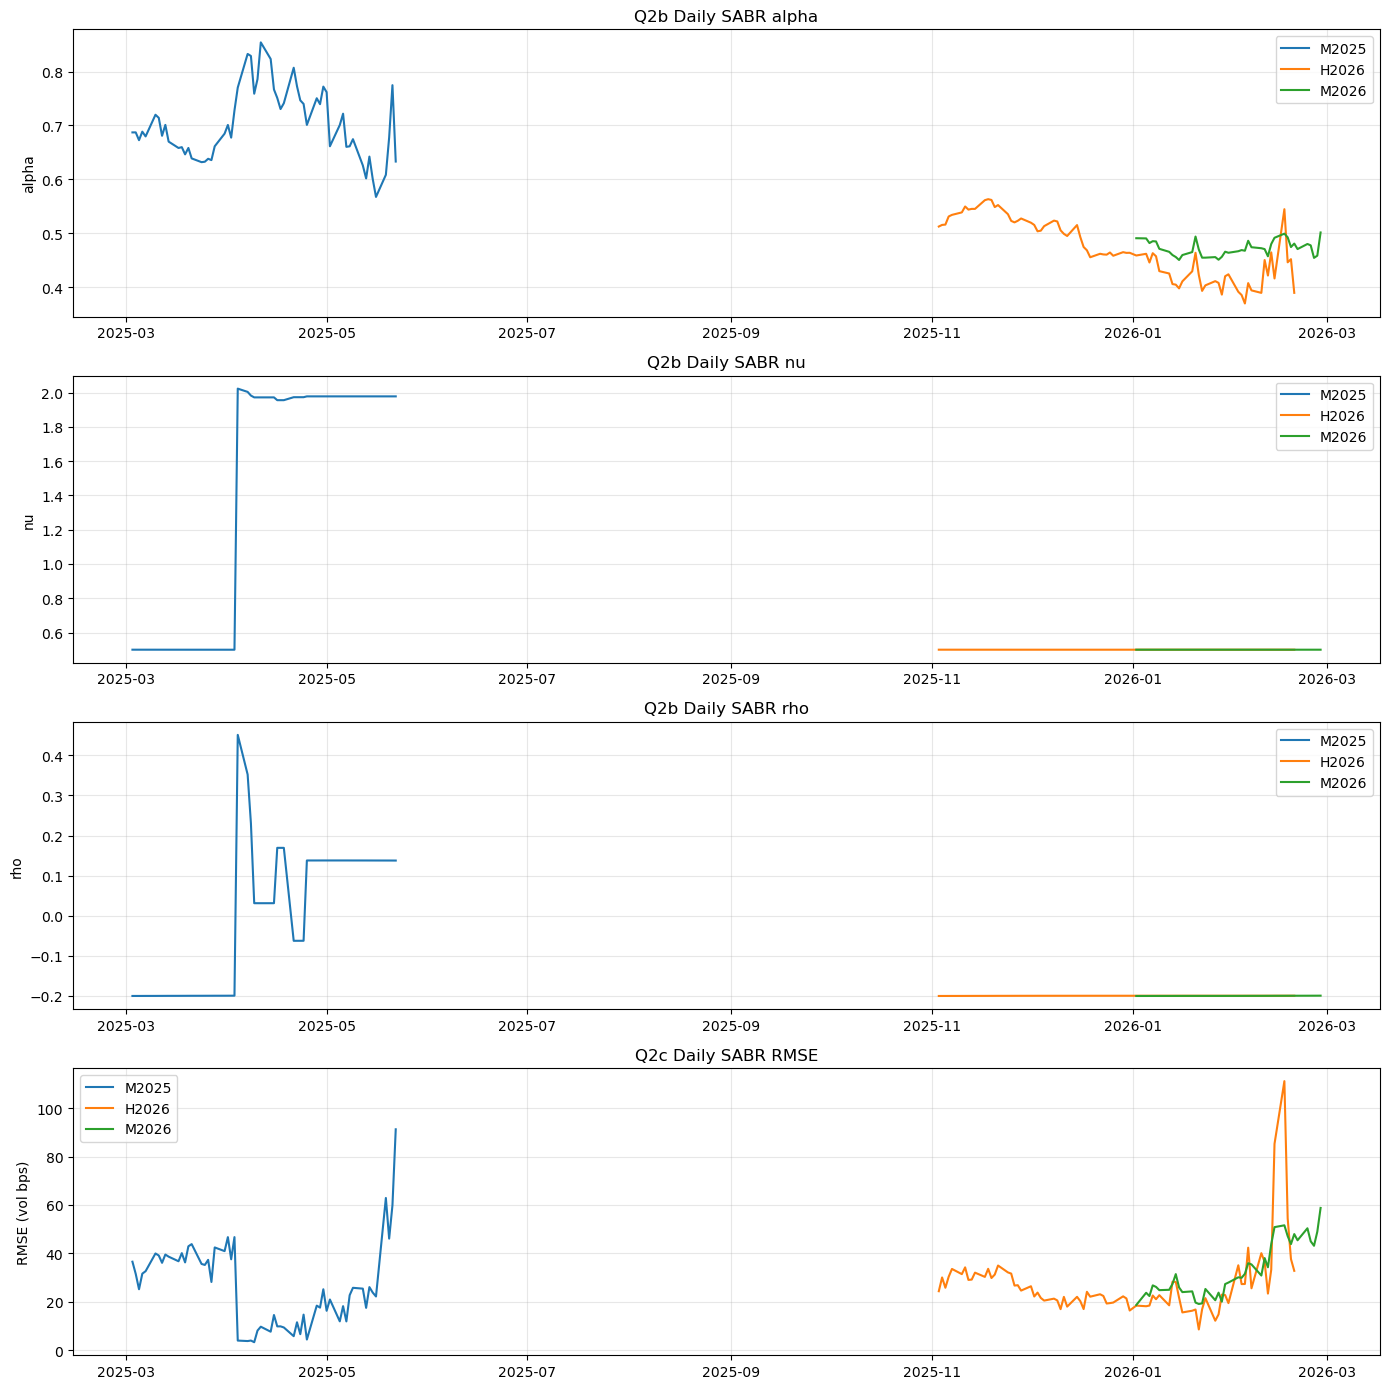

In [8]:
# Q2b/Q2c: Daily SABR calibrations across all contracts
daily_calib = {}
for contract, surf in surfs.items():
    print(f'Calibrating {contract} ({len(surf)} dates) ...')
    daily_calib[contract] = run_daily_calibration(surf, contract_name=contract, beta=beta, sides=('P', 'C'))

all_calib = pd.concat(daily_calib.values(), axis=0).sort_index()
all_calib.index.name = 'date'

print('\\nCalibration counts and success rates:')
print(all_calib.groupby('contract')['success'].agg(['count', 'mean']).rename(columns={'mean': 'success_rate'}).round(4).to_string())

summary_stats = all_calib.groupby('contract')[['alpha', 'nu', 'rho', 'rmse', 'atm_vol']].agg(['mean', 'std', 'min', 'max'])
print('\\nQ2b summary statistics by contract:')
print(summary_stats.round(6).to_string())

worst_fits = all_calib.sort_values('rmse', ascending=False).head(10)
print('\\nQ2c worst RMSE dates (top 10):')
print(worst_fits[['contract', 'alpha', 'nu', 'rho', 'rmse', 'atm_vol', 'success']].round(6).to_string())

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=False)
for contract, df in daily_calib.items():
    axes[0].plot(df.index, df['alpha'], label=contract)
    axes[1].plot(df.index, df['nu'], label=contract)
    axes[2].plot(df.index, df['rho'], label=contract)
    axes[3].plot(df.index, df['rmse'] * 1e4, label=contract)

axes[0].set_title('Q2b Daily SABR alpha')
axes[0].set_ylabel('alpha')
axes[1].set_title('Q2b Daily SABR nu')
axes[1].set_ylabel('nu')
axes[2].set_title('Q2b Daily SABR rho')
axes[2].set_ylabel('rho')
axes[3].set_title('Q2c Daily SABR RMSE')
axes[3].set_ylabel('RMSE (vol bps)')

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

### Interpretation for Q2
- **Q2a single-date fit:** For the representative date, the calibrated parameters are approximately **α = 0.671**, **ν = 0.400**, **ρ = -0.200**, with **RMSE = 0.00374** (about 37 vol bps). The fit is good but not perfect in the wings.
- **Q2b daily calibration:** All contracts calibrate successfully on every date (100% success). Parameter stability differs by contract:
  - `H2026` and `M2026` are very stable (`ν ≈ 0.5`, `ρ ≈ -0.2` almost constant).
  - `M2025` is much more regime-sensitive (`ν` ranges roughly **0.50 to 2.02**, `ρ` from **-0.20 to +0.45**).
- **Q2c fit quality:** Worst fits cluster in event-heavy days (notably Apr/May 2025 and Feb 2026), with max RMSE around **0.0111** (111 vol bps). Typical RMSE remains much lower for all contracts.

### Question 3: Calibration Quality and Regime Identification

Using the daily SABR calibrations from Q2, analyze when and why the model works well versus poorly.

a) Plot the daily fit RMSE (from Q2c) over time alongside ATM vol. Is there a systematic relationship between market volatility and calibration quality?

b) Rank all trading days by the magnitude of day-over-day SABR parameter changes (e.g., $|\Delta\nu| + |\Delta\rho|$, or another metric of your choice). Report the top 5 dates across all contracts. For 2–3 of the largest, display the pre- and post-day smiles and identify what drove the change.

c) For the January–February 2026 window where H2026 and M2026 overlap in calendar time, compare SABR parameters calibrated on the same dates across the two contracts. Does smile shape depend on how far out the option expires?

d) Test a "lazy recalibration" approach: hold $(\nu, \rho)$ fixed at their values from $N$ days ago (e.g., $N$ = 5, 10, 20) and update only $\alpha$ via the ATM constraint each day. Measure the resulting RMSE and compare it to full daily recalibration. How quickly do stale parameters degrade the fit, and what does this imply for recalibration frequency?

Q3a correlation between RMSE and ATM vol by contract:
          corr_rmse_atmvol
contract                  
M2025            -0.572935
H2026             0.138663
M2026             0.302917


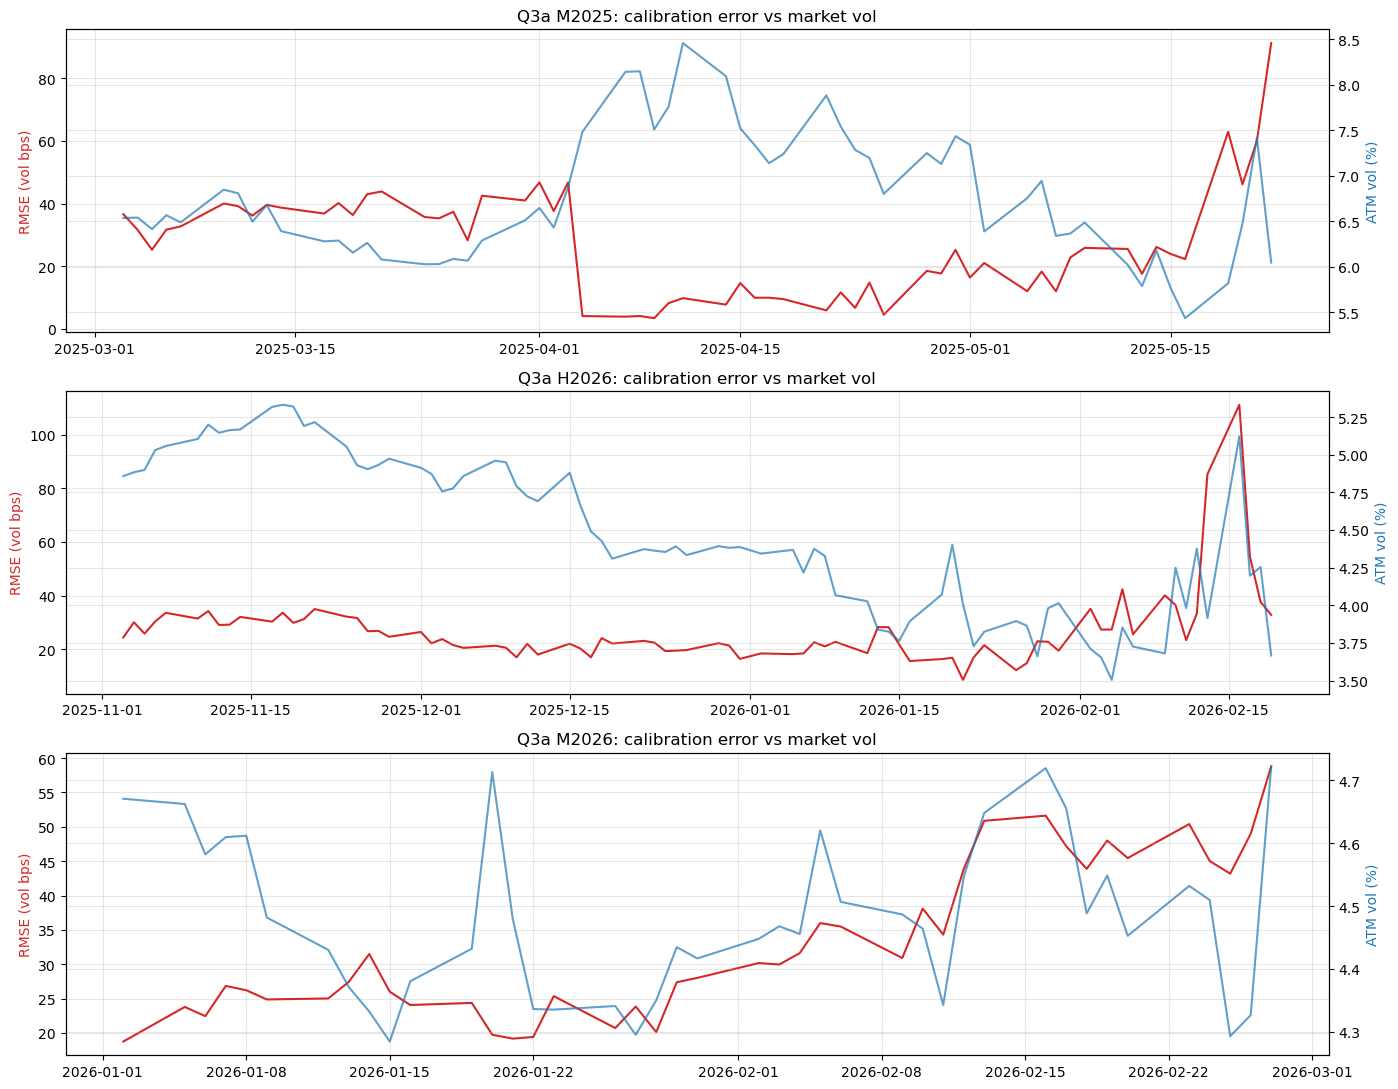

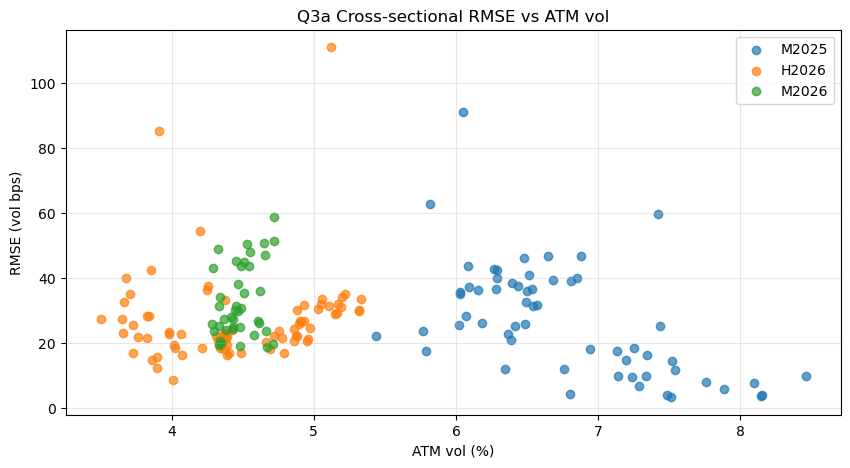

In [9]:
# Q3a: RMSE vs ATM-vol relationship
corr_rows = []
for contract, df in daily_calib.items():
    c = df[['rmse', 'atm_vol']].corr().iloc[0, 1]
    corr_rows.append({'contract': contract, 'corr_rmse_atmvol': c})

corr_table = pd.DataFrame(corr_rows).set_index('contract')
print('Q3a correlation between RMSE and ATM vol by contract:')
print(corr_table.round(6).to_string())

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
for ax, (contract, df) in zip(axes, daily_calib.items()):
    ax2 = ax.twinx()
    ax.plot(df.index, df['rmse'] * 1e4, color='tab:red', label='RMSE (vol bps)')
    ax2.plot(df.index, df['atm_vol'] * 100, color='tab:blue', alpha=0.7, label='ATM vol (%)')

    ax.set_title(f'Q3a {contract}: calibration error vs market vol')
    ax.set_ylabel('RMSE (vol bps)', color='tab:red')
    ax2.set_ylabel('ATM vol (%)', color='tab:blue')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for contract, df in daily_calib.items():
    ax.scatter(df['atm_vol'] * 100, df['rmse'] * 1e4, alpha=0.7, label=contract)

ax.set_title('Q3a Cross-sectional RMSE vs ATM vol')
ax.set_xlabel('ATM vol (%)')
ax.set_ylabel('RMSE (vol bps)')
ax.legend()
plt.show()

Q3b top 5 parameter-jump dates across all contracts:
           contract  jump_metric      d_nu     d_rho  d_atm_vol  d_skew_25
date                                                                      
2025-04-04    M2025     2.172974  1.522776  0.650198   0.006114  -0.008621
2025-04-21    M2025     0.249102  0.017375 -0.231727   0.006412   0.004935
2025-04-09    M2025     0.209657 -0.010548 -0.199109  -0.006441   0.008100
2025-04-25    M2025     0.204998  0.004802  0.200196  -0.003930  -0.002577
2025-04-16    M2025     0.154270 -0.016284  0.137986  -0.001843  -0.000450


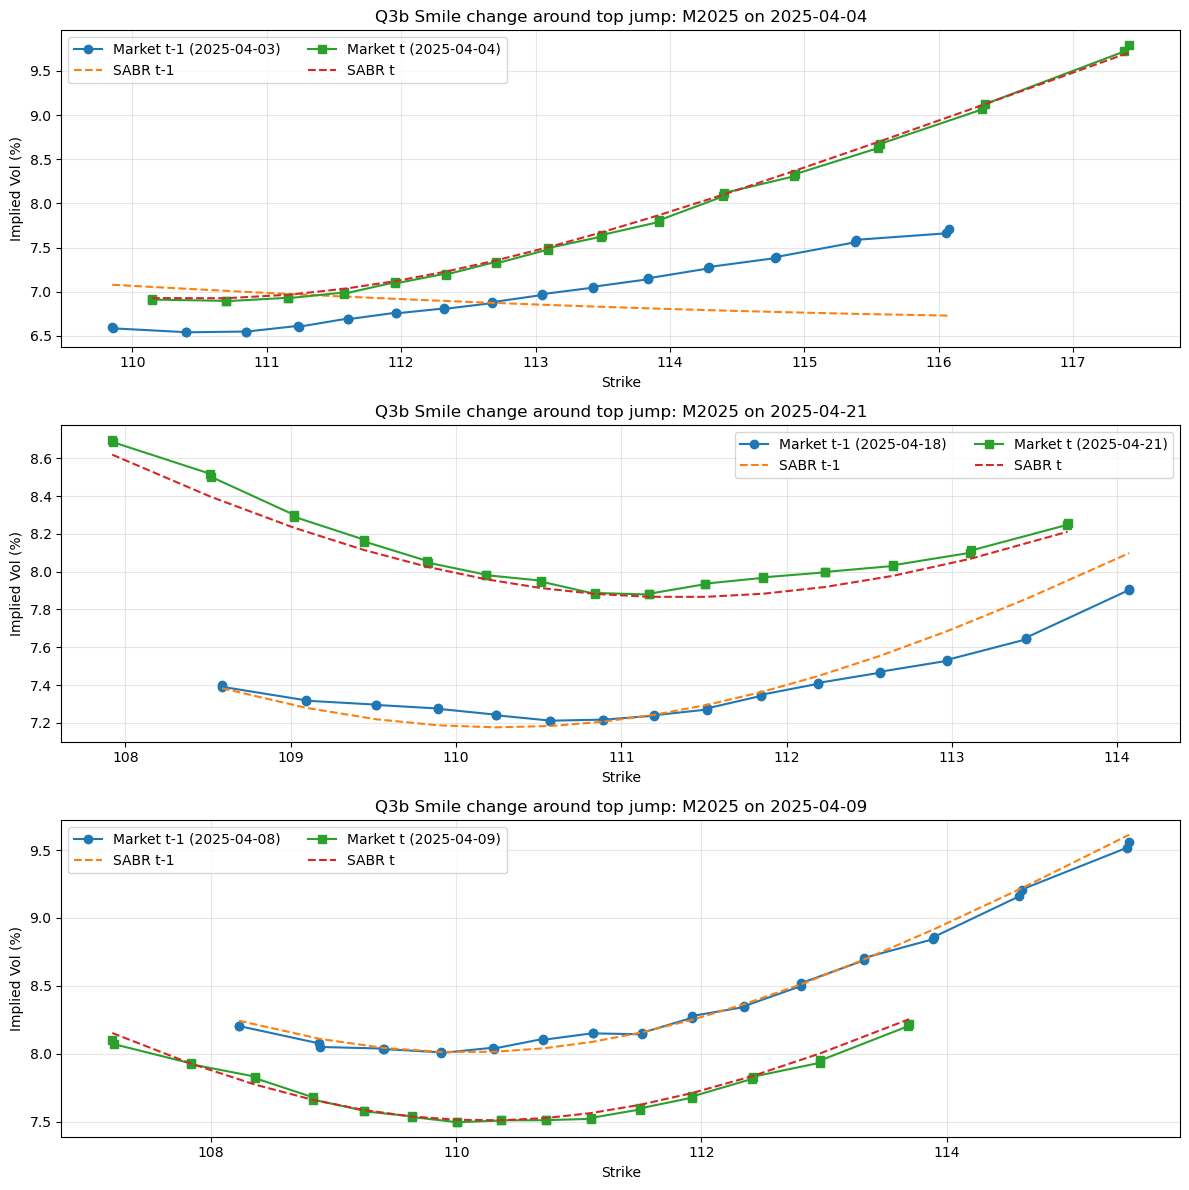

\nQ3b driver table for plotted events:
           contract  jump_metric   d_alpha      d_nu     d_rho  d_atm_vol  d_skew_25
date                                                                                
2025-04-04    M2025     2.172974  0.042397  1.522776  0.650198   0.006114  -0.008621
2025-04-21    M2025     0.249102  0.065801  0.017375 -0.231727   0.006412   0.004935
2025-04-09    M2025     0.209657 -0.069960 -0.010548 -0.199109  -0.006441   0.008100


In [10]:
# Q3b: Parameter-jump ranking and smile diagnostics
jump_tables = {}
for contract, df in daily_calib.items():
    tmp = df.copy()
    tmp['d_alpha'] = tmp['alpha'].diff()
    tmp['d_nu'] = tmp['nu'].diff()
    tmp['d_rho'] = tmp['rho'].diff()
    tmp['jump_metric'] = tmp['d_nu'].abs() + tmp['d_rho'].abs()

    surf = surfs[contract].reindex(tmp.index)
    tmp['atm_vol'] = surf['P50dvol'].to_numpy(dtype=float)
    tmp['d_atm_vol'] = tmp['atm_vol'].diff()
    tmp['skew_25'] = surf['P25dvol'].to_numpy(dtype=float) - surf['C25dvol'].to_numpy(dtype=float)
    tmp['d_skew_25'] = tmp['skew_25'].diff()

    jump_tables[contract] = tmp

jump_all = pd.concat(jump_tables.values(), axis=0).sort_index()
jump_all.index.name = 'date'

top5_param_jumps = jump_all.dropna(subset=['jump_metric']).sort_values('jump_metric', ascending=False).head(5)
print('Q3b top 5 parameter-jump dates across all contracts:')
print(top5_param_jumps[['contract', 'jump_metric', 'd_nu', 'd_rho', 'd_atm_vol', 'd_skew_25']].round(6).to_string())

events_for_plot = top5_param_jumps.head(3)
fig, axes = plt.subplots(len(events_for_plot), 1, figsize=(12, 4 * len(events_for_plot)))
if len(events_for_plot) == 1:
    axes = [axes]

for ax, (dt, row_evt) in zip(axes, events_for_plot.iterrows()):
    contract = row_evt['contract']
    dates = daily_calib[contract].index
    pos = dates.get_loc(dt)
    if isinstance(pos, slice):
        pos = pos.start
    if pos == 0:
        continue

    prev_dt = dates[pos - 1]
    prev_row = surfs[contract].loc[prev_dt]
    curr_row = surfs[contract].loc[dt]

    prev_smile = extract_smile_from_row(prev_row, sides=('P', 'C'))
    curr_smile = extract_smile_from_row(curr_row, sides=('P', 'C'))

    prev_par = daily_calib[contract].loc[prev_dt]
    curr_par = daily_calib[contract].loc[dt]

    prev_model = sabr_vol_hagan(
        prev_row['Future Price'],
        prev_smile['strike'].to_numpy(),
        prev_row['Expiration Option'],
        prev_par['alpha'], beta, prev_par['rho'], prev_par['nu']
    )
    curr_model = sabr_vol_hagan(
        curr_row['Future Price'],
        curr_smile['strike'].to_numpy(),
        curr_row['Expiration Option'],
        curr_par['alpha'], beta, curr_par['rho'], curr_par['nu']
    )

    ax.plot(prev_smile['strike'], prev_smile['vol'] * 100, 'o-', label=f'Market t-1 ({prev_dt.date()})')
    ax.plot(prev_smile['strike'], prev_model * 100, '--', label='SABR t-1')
    ax.plot(curr_smile['strike'], curr_smile['vol'] * 100, 's-', label=f'Market t ({dt.date()})')
    ax.plot(curr_smile['strike'], curr_model * 100, '--', label='SABR t')

    ax.set_title(f'Q3b Smile change around top jump: {contract} on {dt.date()}')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied Vol (%)')
    ax.legend(ncol=2)

plt.tight_layout()
plt.show()

print('\\nQ3b driver table for plotted events:')
print(events_for_plot[['contract', 'jump_metric', 'd_alpha', 'd_nu', 'd_rho', 'd_atm_vol', 'd_skew_25']].round(6).to_string())

Q3c overlap days in Jan-Feb 2026: 35


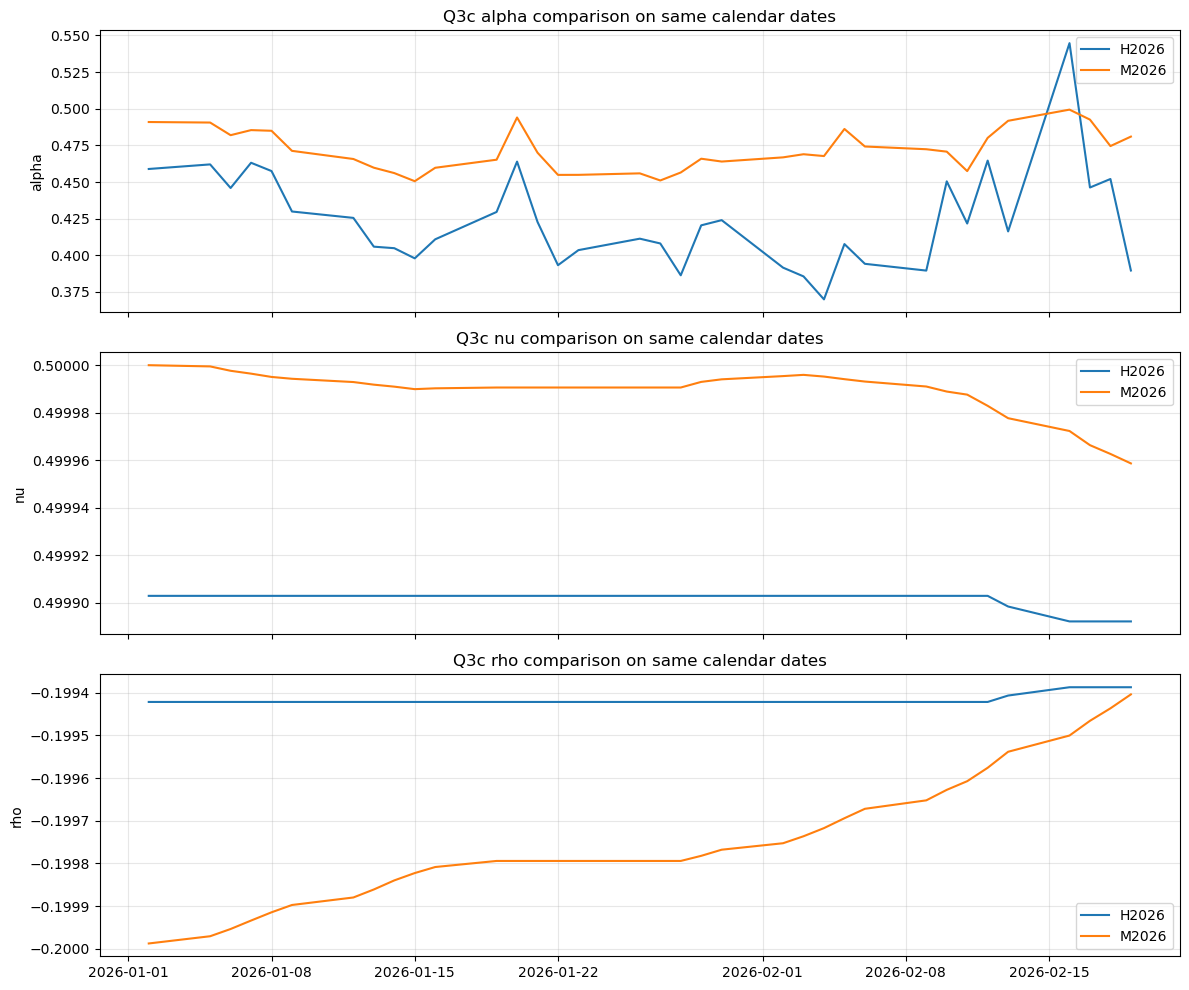

Q3c overlap summary statistics:
       mean_H2026  mean_M2026  mean_diff_M_minus_H  corr_same_day
alpha    0.424274    0.471800             0.047526       0.656064
nu       0.499902    0.499989             0.000087       0.924265
rho     -0.199417   -0.199747            -0.000330       0.755289


In [11]:
# Q3c: Overlap analysis between H2026 and M2026 (Jan-Feb 2026)
overlap = daily_calib['H2026'][['alpha', 'nu', 'rho', 'rmse']].join(
    daily_calib['M2026'][['alpha', 'nu', 'rho', 'rmse']],
    how='inner',
    lsuffix='_H2026',
    rsuffix='_M2026'
)
overlap = overlap.loc['2026-01-01':'2026-02-28']

print(f'Q3c overlap days in Jan-Feb 2026: {len(overlap)}')

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, p in zip(axes, ['alpha', 'nu', 'rho']):
    ax.plot(overlap.index, overlap[f'{p}_H2026'], label='H2026')
    ax.plot(overlap.index, overlap[f'{p}_M2026'], label='M2026')
    ax.set_title(f'Q3c {p} comparison on same calendar dates')
    ax.set_ylabel(p)
    ax.legend()

plt.tight_layout()
plt.show()

diff_summary = pd.DataFrame({
    'mean_H2026': [overlap['alpha_H2026'].mean(), overlap['nu_H2026'].mean(), overlap['rho_H2026'].mean()],
    'mean_M2026': [overlap['alpha_M2026'].mean(), overlap['nu_M2026'].mean(), overlap['rho_M2026'].mean()],
    'mean_diff_M_minus_H': [
        (overlap['alpha_M2026'] - overlap['alpha_H2026']).mean(),
        (overlap['nu_M2026'] - overlap['nu_H2026']).mean(),
        (overlap['rho_M2026'] - overlap['rho_H2026']).mean(),
    ],
    'corr_same_day': [
        overlap[['alpha_H2026', 'alpha_M2026']].corr().iloc[0, 1],
        overlap[['nu_H2026', 'nu_M2026']].corr().iloc[0, 1],
        overlap[['rho_H2026', 'rho_M2026']].corr().iloc[0, 1],
    ],
}, index=['alpha', 'nu', 'rho'])

print('Q3c overlap summary statistics:')
print(diff_summary.round(6).to_string())

Q3d lazy recalibration summary (ratio > 1 means worse than full recalibration):
contract  N_days  mean_ratio  median_ratio  p90_ratio  mean_diff_bpvol
   M2025       5      2.6542        1.0002     5.4263           8.9113
   M2025      10      3.0524        1.0004     6.0906          11.2289
   M2025      20      3.6139        1.5243     6.6917          14.7848
   H2026       5      1.0000        1.0000     1.0001           0.0012
   H2026      10      1.0001        1.0000     1.0003           0.0021
   H2026      20      1.0001        1.0000     1.0004           0.0028
   M2026       5      1.0001        1.0001     1.0001           0.0031
   M2026      10      1.0001        1.0002     1.0002           0.0055
   M2026      20      1.0003        1.0002     1.0004           0.0108


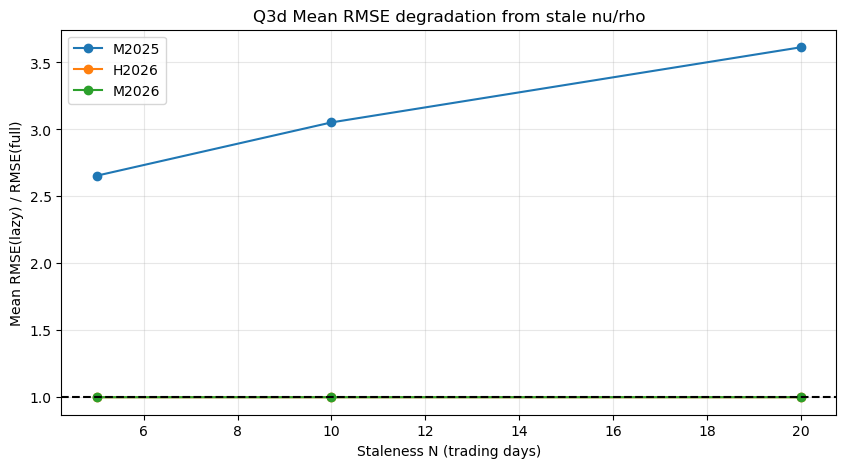

In [12]:
# Q3d: Lazy recalibration (stale nu/rho, fresh alpha)
def lazy_recalibration_rmse(surface_df, full_param_df, N, beta=0.5, sides=('P', 'C')):
    records = []
    dates = full_param_df.index

    for i, dt in enumerate(dates):
        if i < N:
            continue

        stale_dt = dates[i - N]
        stale = full_param_df.loc[stale_dt]
        row = surface_df.loc[dt]

        smile = extract_smile_from_row(row, sides=sides)
        F = float(row['Future Price'])
        T = float(row['Expiration Option'])
        atm_vol = float(np.nanmean([row.get('P50dvol', np.nan), row.get('C50dvol', np.nan)]))

        alpha_lazy = solve_alpha_from_atm(F, T, atm_vol, beta, stale['rho'], stale['nu'])
        model_lazy = sabr_vol_hagan(F, smile['strike'].to_numpy(), T, alpha_lazy, beta, stale['rho'], stale['nu'])
        rmse_lazy = float(np.sqrt(np.mean((model_lazy - smile['vol'].to_numpy()) ** 2)))

        records.append({
            'date': dt,
            'stale_date': stale_dt,
            'N_days': N,
            'alpha_lazy': alpha_lazy,
            'nu_stale': stale['nu'],
            'rho_stale': stale['rho'],
            'rmse_lazy': rmse_lazy,
        })

    return pd.DataFrame(records).set_index('date').sort_index()

N_values = [5, 10, 20]
lazy_results = {}
comparison_rows = []

for contract, df in daily_calib.items():
    for N in N_values:
        lazy_df = lazy_recalibration_rmse(surfs[contract], df, N=N, beta=beta, sides=('P', 'C'))
        merged = lazy_df.join(df[['rmse']], how='inner')
        merged = merged[merged['rmse'] > 1e-10]
        merged['rmse_ratio_lazy_to_full'] = merged['rmse_lazy'] / merged['rmse']
        merged['rmse_diff_bpvol'] = (merged['rmse_lazy'] - merged['rmse']) * 1e4

        lazy_results[(contract, N)] = merged

        comparison_rows.append({
            'contract': contract,
            'N_days': N,
            'mean_ratio': merged['rmse_ratio_lazy_to_full'].mean(),
            'median_ratio': merged['rmse_ratio_lazy_to_full'].median(),
            'p90_ratio': merged['rmse_ratio_lazy_to_full'].quantile(0.9),
            'mean_diff_bpvol': merged['rmse_diff_bpvol'].mean(),
        })

lazy_summary = pd.DataFrame(comparison_rows)
print('Q3d lazy recalibration summary (ratio > 1 means worse than full recalibration):')
print(lazy_summary.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
for contract in daily_calib.keys():
    sub = lazy_summary[lazy_summary['contract'] == contract]
    ax.plot(sub['N_days'], sub['mean_ratio'], marker='o', label=contract)

ax.axhline(1.0, color='black', linestyle='--')
ax.set_title('Q3d Mean RMSE degradation from stale nu/rho')
ax.set_xlabel('Staleness N (trading days)')
ax.set_ylabel('Mean RMSE(lazy) / RMSE(full)')
ax.legend()
plt.show()

### Interpretation for Q3
- **Q3a (RMSE vs vol):** The RMSE-vol relationship is contract-specific, not monotone across the board. Correlations are about **-0.57 (M2025)**, **+0.14 (H2026)**, and **+0.30 (M2026)**. This suggests fit difficulty is driven by smile-shape transitions, not just higher ATM level.
- **Q3b (largest parameter jumps):** The top jump dates are concentrated in `M2025`, with **2025-04-04** dominant (`|Δν|+|Δρ| ≈ 2.17`). On that date, both level and skew changed materially (`ΔATM vol ≈ +61 bps`, skew shifted), consistent with a regime break.
- **Q3c (H2026 vs M2026 overlap):** On common Jan-Feb 2026 dates, `ν` and `ρ` are highly aligned across maturities (same-day correlations ~0.92 and ~0.76), while `α` is systematically higher for `M2026` (mean difference ~+0.048). Maturity mainly loads into level (`α`) rather than the stochastic-shape terms.
- **Q3d (lazy recalibration):** Stale parameters degrade quickly for `M2025` (mean RMSE ratio rises from **2.65x** at N=5 to **3.61x** at N=20), but barely degrade for `H2026/M2026` (near **1.00x**). Recalibration frequency should therefore be regime- and contract-dependent.

### Question 4: Listed vs. OTC — Cross-Product Comparison

Using the swaption smile data from C.8.1 (`swaption_smile_daily_2025.xlsx`), compare SABR dynamics for Treasury futures options vs. 1Yx5Y swaptions during April 2025—the one window where both products have data.

a) Calibrate SABR ($\beta = 0.5$) to the 1Yx5Y swaption smile for each day in April 2025. Plot the $(\alpha, \nu, \rho)$ time series for both products on the same axes.

b) On the dates with the largest day-over-day parameter changes (which you identified in Q3b for TY options), compare the corresponding swaption parameter changes. Do the two markets agree on the direction and magnitude of $\nu$ and $\rho$ changes?

c) Normalize each product's smile by its ATM vol on the same date and overlay them. Are the shapes similar, or do the two markets price tail risk differently?

d) Discuss possible reasons for any differences you observe.

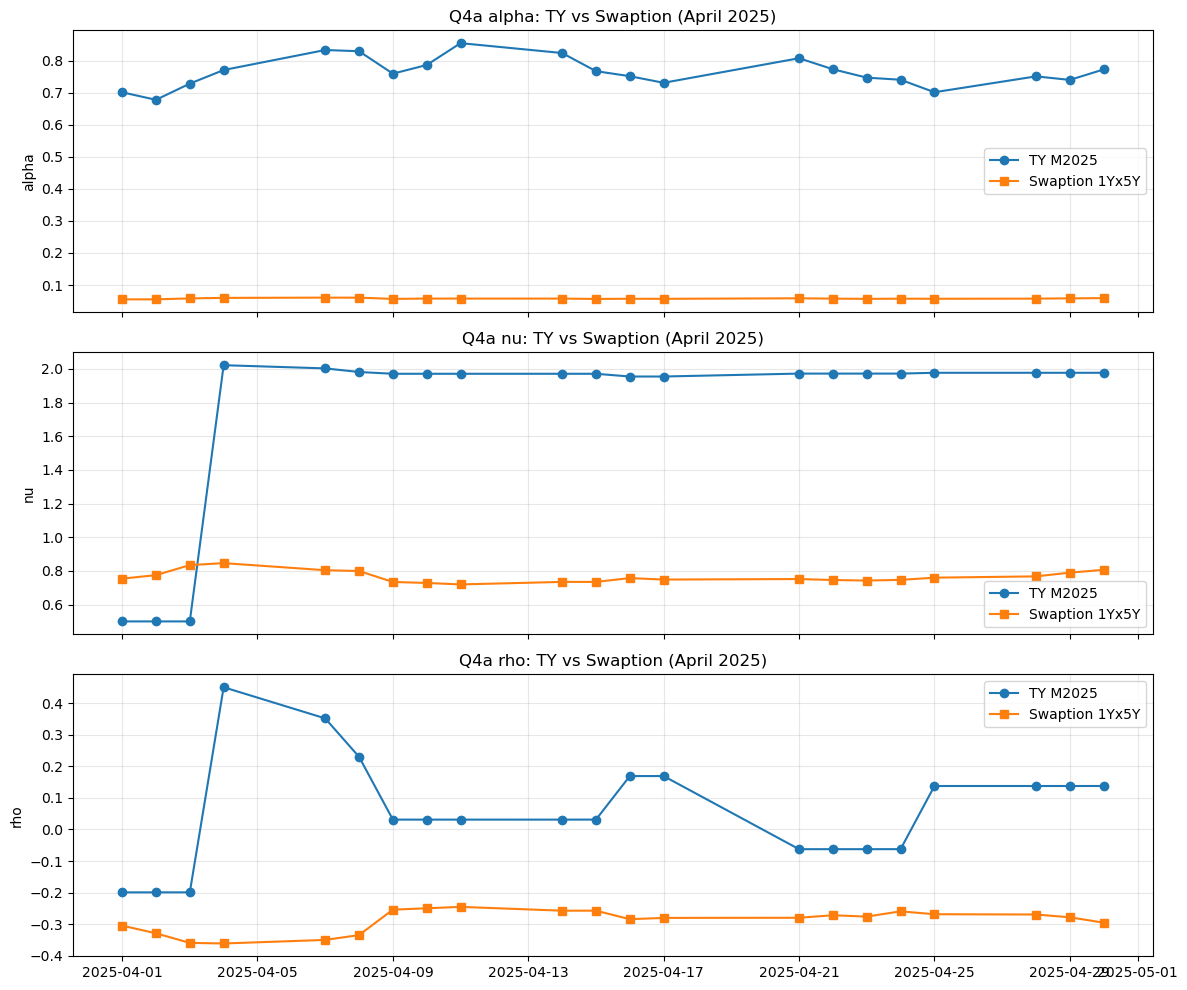

Q4a summary (April overlap):
      TY_M2025                                        Swaption_1Yx5Y                                        
         alpha        nu       rho      rmse  atm_vol          alpha        nu       rho      rmse   atm_vol
mean  0.763749  1.765544  0.058690  0.001484  0.07433       0.057898  0.765741 -0.288925  0.011994  0.319167
std   0.046262  0.529683  0.170458  0.001342  0.00523       0.001430  0.035058  0.036741  0.003505  0.011883


In [13]:
# Q4a: Daily SABR calibration for 1Yx5Y swaptions (April 2025)
def calibrate_swaption_daily(beta=0.5):
    common_dates = swaption_black_vol.index.intersection(swaption_atm_forward.index).intersection(swaption_abs_strikes.index)
    out = []
    guess = (0.4, -0.2)

    for dt in common_dates:
        F = float(swaption_atm_forward.loc[dt, 'atm_fwd_pct']) / 100.0
        strikes = swaption_abs_strikes.loc[dt].to_numpy(dtype=float) / 100.0
        vols = swaption_black_vol.loc[dt].to_numpy(dtype=float) / 100.0
        atm_vol = float(swaption_black_vol.loc[dt, 0]) / 100.0

        fit = calibrate_sabr_smile(
            F=F,
            T=1.0,
            strikes=strikes,
            market_vols=vols,
            atm_vol=atm_vol,
            beta=beta,
            initial_guess=guess,
            bounds=((1e-4, 5.0), (-0.999, 0.999)),
        )
        guess = (fit['nu'], fit['rho'])

        out.append({
            'date': dt,
            'alpha': fit['alpha'],
            'nu': fit['nu'],
            'rho': fit['rho'],
            'rmse': fit['rmse'],
            'atm_vol': atm_vol,
        })

    return pd.DataFrame(out).set_index('date').sort_index()

swaption_calib = calibrate_swaption_daily(beta=beta)

common_apr = daily_calib['M2025'].index.intersection(swaption_calib.index)
ty_apr = daily_calib['M2025'].loc[common_apr]
sw_apr = swaption_calib.loc[common_apr]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, p in zip(axes, ['alpha', 'nu', 'rho']):
    ax.plot(common_apr, ty_apr[p], marker='o', label='TY M2025')
    ax.plot(common_apr, sw_apr[p], marker='s', label='Swaption 1Yx5Y')
    ax.set_title(f'Q4a {p}: TY vs Swaption (April 2025)')
    ax.set_ylabel(p)
    ax.legend()

plt.tight_layout()
plt.show()

q4a_summary = pd.concat(
    {
        'TY_M2025': ty_apr[['alpha', 'nu', 'rho', 'rmse', 'atm_vol']].agg(['mean', 'std']),
        'Swaption_1Yx5Y': sw_apr[['alpha', 'nu', 'rho', 'rmse', 'atm_vol']].agg(['mean', 'std']),
    },
    axis=1,
)
print('Q4a summary (April overlap):')
print(q4a_summary.round(6).to_string())

Q4b TY top-jump dates vs swaption parameter changes:
           ty_contract   ty_d_nu  ty_d_rho  swap_d_nu  swap_d_rho  nu_same_sign  rho_same_sign
date                                                                                          
2025-04-04       M2025  1.522776  0.650198   0.011792   -0.001825          True          False
2025-04-09       M2025 -0.010548 -0.199109  -0.064925    0.080573          True          False
2025-04-16       M2025 -0.016284  0.137986   0.022728   -0.027006         False          False
2025-04-21       M2025  0.017375 -0.231727   0.003129    0.000488          True          False
2025-04-25       M2025  0.004802  0.200196   0.013199   -0.009172          True          False


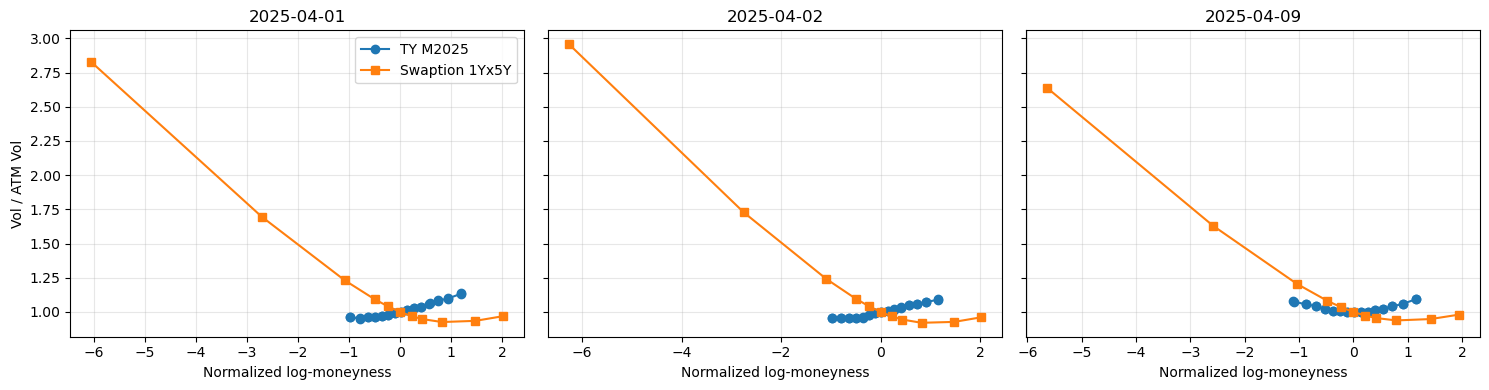

Q4c/Q4d normalized-tail diagnostics:
                     left_tail_x=-2  right_tail_x=+2  tail_asymmetry_left_minus_right
date       product                                                                   
2025-04-01 Swaption        1.491998         0.968382                         0.523616
           TY              0.962313         1.135112                        -0.172799
2025-04-02 Swaption        1.507208         0.959951                         0.547256
           TY              0.958032         1.096330                        -0.138298
2025-04-09 Swaption        1.469516         0.980869                         0.488647
           TY              1.079103         1.094488                        -0.015385


In [14]:
# Q4b/Q4c/Q4d: Parameter-change alignment and normalized smile overlays
sw_deltas = swaption_calib[['nu', 'rho']].diff().rename(columns={'nu': 'swap_d_nu', 'rho': 'swap_d_rho'})

q4b_rows = []
for dt, row_evt in top5_param_jumps.iterrows():
    q4b_rows.append({
        'date': dt,
        'ty_contract': row_evt['contract'],
        'ty_d_nu': row_evt['d_nu'],
        'ty_d_rho': row_evt['d_rho'],
        'swap_d_nu': sw_deltas.loc[dt, 'swap_d_nu'] if dt in sw_deltas.index else np.nan,
        'swap_d_rho': sw_deltas.loc[dt, 'swap_d_rho'] if dt in sw_deltas.index else np.nan,
    })

q4b_table = pd.DataFrame(q4b_rows).set_index('date').sort_index()
q4b_table['nu_same_sign'] = np.sign(q4b_table['ty_d_nu']) == np.sign(q4b_table['swap_d_nu'])
q4b_table['rho_same_sign'] = np.sign(q4b_table['ty_d_rho']) == np.sign(q4b_table['swap_d_rho'])

print('Q4b TY top-jump dates vs swaption parameter changes:')
print(q4b_table.round(6).to_string())

overlay_targets = ['2025-04-01', '2025-04-02', '2025-04-09']
overlay_dates = [d for d in map(pd.Timestamp, overlay_targets) if d in swaption_calib.index and d in daily_calib['M2025'].index]

fig, axes = plt.subplots(1, len(overlay_dates), figsize=(5 * len(overlay_dates), 4), sharey=True)
if len(overlay_dates) == 1:
    axes = [axes]

tail_rows = []
for ax, dt in zip(axes, overlay_dates):
    ty_row = surfs['M2025'].loc[dt]
    ty_smile = extract_smile_from_row(ty_row, sides=('P', 'C'))
    ty_norm = normalize_smile(ty_smile['strike'], ty_smile['vol'], ty_row['Future Price'], ty_row['Expiration Option'])

    F_sw = float(swaption_atm_forward.loc[dt, 'atm_fwd_pct']) / 100.0
    K_sw = swaption_abs_strikes.loc[dt].to_numpy(dtype=float) / 100.0
    vol_sw = swaption_black_vol.loc[dt].to_numpy(dtype=float) / 100.0
    sw_norm = normalize_smile(K_sw, vol_sw, F_sw, T=1.0)

    ax.plot(ty_norm['x_norm'], ty_norm['vol_norm'], 'o-', label='TY M2025')
    ax.plot(sw_norm['x_norm'], sw_norm['vol_norm'], 's-', label='Swaption 1Yx5Y')
    ax.set_title(str(dt.date()))
    ax.set_xlabel('Normalized log-moneyness')

    for name, df in [('TY', ty_norm), ('Swaption', sw_norm)]:
        x = df['x_norm'].to_numpy()
        y = df['vol_norm'].to_numpy()
        order = np.argsort(x)
        x_s = x[order]
        y_s = y[order]
        left = float(np.interp(-2.0, x_s, y_s))
        right = float(np.interp(2.0, x_s, y_s))
        tail_rows.append({
            'date': dt,
            'product': name,
            'left_tail_x=-2': left,
            'right_tail_x=+2': right,
            'tail_asymmetry_left_minus_right': left - right,
        })

axes[0].set_ylabel('Vol / ATM Vol')
axes[0].legend()
plt.tight_layout()
plt.show()

tail_diag = pd.DataFrame(tail_rows).set_index(['date', 'product']).sort_index()
print('Q4c/Q4d normalized-tail diagnostics:')
print(tail_diag.round(6).to_string())

### Interpretation for Q4
- **Q4a (TY vs swaption parameter dynamics):** Over April 2025, TY (`M2025`) has much higher vol-of-vol on average (**ν ≈ 1.77**) than swaptions (**ν ≈ 0.77**) and slightly positive average `ρ` (**+0.059**) versus persistently negative swaption `ρ` (**-0.289**). The two markets are not just scaled versions of the same smile process.
- **Q4b (event-date change alignment):** On TY top-jump dates, `ν` direction matches swaptions in most cases (4/5), but `ρ` direction is opposite on all listed dates (0/5 same-sign). So both markets register stress, but through different skew mechanics.
- **Q4c (normalized smile overlays):** Swaptions consistently price a much heavier normalized left tail (tail asymmetry about **+0.49 to +0.55**), while TY shows right-tail richness pre-shock and near-symmetry by Apr 9 (asymmetry from about **-0.17** to **-0.02**).
- **Q4d (economic interpretation):** Differences are plausible given product structure: deliverable CTD/futures optionality, different investor bases and hedging flows, and OTC balance-sheet/credit/liquidity premia in swaption markets.

### Question 5: Practical Implications — Augmented Delta Across Regimes

A dealer is short a put on TY futures struck 50 basis points below ATM.

a) Compute the **Black delta** and the **SABR augmented delta** ($\Delta_{\text{SABR}} = \Delta_{\text{Black}} + \mathcal{V} \cdot \frac{\partial \sigma}{\partial F}$, where $\frac{\partial \sigma}{\partial F}$ is computed by finite difference) on two dates: one from the most volatile period you identified in Q3 and one from a calm period.

b) How much does the hedge ratio correction differ across regimes? Express the difference as a percentage of the Black delta. Under what market conditions is the SABR correction most economically significant?

c) Connect your findings to the regime analysis from Q3 and the recalibration question from Q3d. If a desk decides to use flat Black delta during quiet markets, what risks do they take when the regime shifts?


Q5a/Q5b two-regime delta comparison:
                      date           F  K_50bp_below  sigma_sabr  black_delta_put  sabr_aug_delta  delta_correction  delta_correction_pct_of_black       vega  dsigma_dF
regime                                                                                                                                                                  
Calm regime     2025-05-07  111.546875    110.989141    0.063062        -0.350019       -0.353794         -0.003776                       1.078707   8.698754  -0.000434
Volatile regime 2025-04-04  113.046875    112.481641    0.072761        -0.418480       -0.477562         -0.059082                      14.118154  16.155975  -0.003657


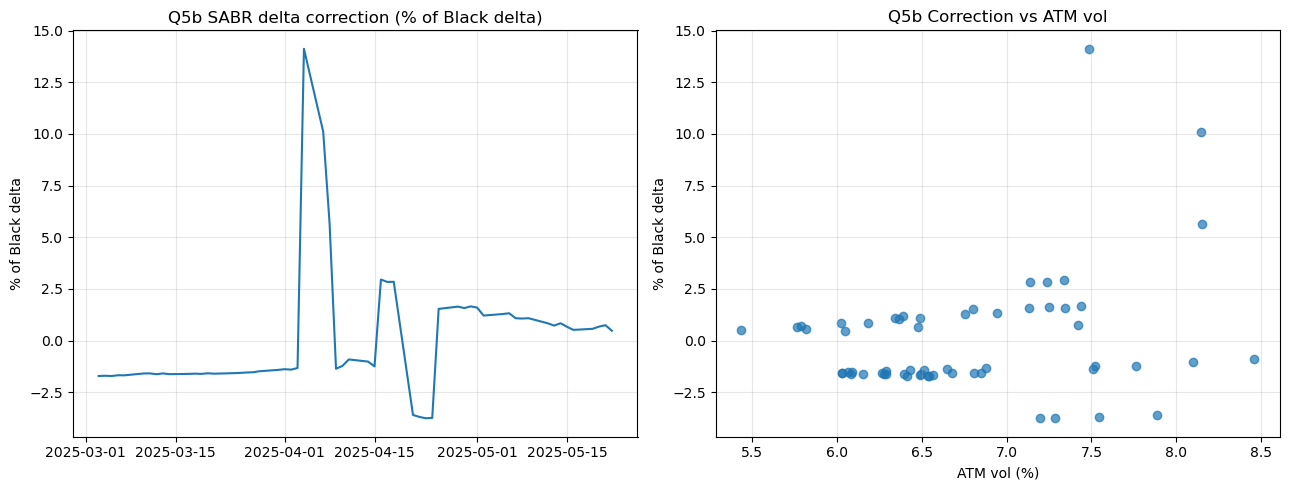

Q5b summary of daily correction (% of Black delta):
count    59.0000
mean      0.0197
std       2.9507
min      -3.7610
25%      -1.5983
50%      -1.2522
75%       1.0801
max      14.1182
Correlation(correction %, ATM vol): 0.2682
Q5c stale-parameter hedge error summary (N=10):
count     49.0000
mean      21.9830
std      163.1534
min     -473.9509
25%       -0.0358
50%        0.1158
75%        3.9482
max      621.0011
Mean |delta error| in high-jump regime (x1e4): 161.8933
Mean |delta error| in low-jump regime  (x1e4): 52.0495


In [15]:
# Q5: Augmented delta across regimes for a put struck 50 bps below ATM
# Assumption: '50 bps below ATM' means strike = F * (1 - 0.005).
def augmented_delta_from_params(F, K, T, r, alpha, nu, rho, beta=0.5):
    sigma = float(sabr_vol_hagan(F, K, T, alpha, beta, rho, nu))
    delta_black = black_futures_put_delta(F, K, T, r, sigma)
    vega = black_futures_vega(F, K, T, r, sigma)

    h = max(1e-4, 1e-4 * F)
    sigma_up = float(sabr_vol_hagan(F + h, K, T, alpha, beta, rho, nu))
    sigma_dn = float(sabr_vol_hagan(F - h, K, T, alpha, beta, rho, nu))
    dsigma_dF = (sigma_up - sigma_dn) / (2.0 * h)

    delta_sabr = delta_black + vega * dsigma_dF
    return delta_black, delta_sabr, vega, dsigma_dF, sigma

m2025_jumps = jump_tables['M2025'].dropna(subset=['jump_metric']).copy()
volatile_date = m2025_jumps['jump_metric'].idxmax()
calm_pool = m2025_jumps.sort_values(['jump_metric', 'atm_vol'])
calm_date = calm_pool.index[0]

selected = {'Calm regime': calm_date, 'Volatile regime': volatile_date}
rows = []

for label, dt in selected.items():
    row = surfs['M2025'].loc[dt]
    pars = daily_calib['M2025'].loc[dt]

    F = float(row['Future Price'])
    T = float(row['Expiration Option'])
    K = F * (1.0 - 0.005)

    r_date = nearest_date(rates.index, dt)
    r = float(rates.loc[r_date, 'SOFR 5Y']) / 100.0

    d_black, d_sabr, vega, dsig_dF, sigma = augmented_delta_from_params(
        F=F,
        K=K,
        T=T,
        r=r,
        alpha=pars['alpha'],
        nu=pars['nu'],
        rho=pars['rho'],
        beta=beta,
    )

    rows.append({
        'regime': label,
        'date': dt,
        'F': F,
        'K_50bp_below': K,
        'sigma_sabr': sigma,
        'black_delta_put': d_black,
        'sabr_aug_delta': d_sabr,
        'delta_correction': d_sabr - d_black,
        'delta_correction_pct_of_black': 100.0 * (d_sabr - d_black) / d_black,
        'vega': vega,
        'dsigma_dF': dsig_dF,
    })

q5_table = pd.DataFrame(rows).set_index('regime')
print('Q5a/Q5b two-regime delta comparison:')
print(q5_table.round(6).to_string())

daily_delta = []
for dt in daily_calib['M2025'].index:
    row = surfs['M2025'].loc[dt]
    pars = daily_calib['M2025'].loc[dt]

    F = float(row['Future Price'])
    T = float(row['Expiration Option'])
    K = F * (1.0 - 0.005)
    r = float(rates.loc[nearest_date(rates.index, dt), 'SOFR 5Y']) / 100.0

    d_black, d_sabr, vega, dsig_dF, sigma = augmented_delta_from_params(
        F=F,
        K=K,
        T=T,
        r=r,
        alpha=pars['alpha'],
        nu=pars['nu'],
        rho=pars['rho'],
        beta=beta,
    )

    daily_delta.append({
        'date': dt,
        'black_delta': d_black,
        'sabr_delta': d_sabr,
        'correction': d_sabr - d_black,
        'correction_pct_black': 100.0 * (d_sabr - d_black) / d_black,
        'atm_vol': pars['atm_vol'],
    })

daily_delta = pd.DataFrame(daily_delta).set_index('date').sort_index()
daily_delta = daily_delta.join(m2025_jumps[['jump_metric']], how='left')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(daily_delta.index, daily_delta['correction_pct_black'])
axes[0].set_title('Q5b SABR delta correction (% of Black delta)')
axes[0].set_ylabel('% of Black delta')

axes[1].scatter(daily_delta['atm_vol'] * 100, daily_delta['correction_pct_black'], alpha=0.7)
axes[1].set_title('Q5b Correction vs ATM vol')
axes[1].set_xlabel('ATM vol (%)')
axes[1].set_ylabel('% of Black delta')

plt.tight_layout()
plt.show()

print('Q5b summary of daily correction (% of Black delta):')
print(daily_delta['correction_pct_black'].describe().round(4).to_string())
print(f"Correlation(correction %, ATM vol): {daily_delta['correction_pct_black'].corr(daily_delta['atm_vol']):.4f}")

N_hedge = 10
hedge_rows = []
dates = daily_calib['M2025'].index

for i, dt in enumerate(dates):
    if i < N_hedge:
        continue

    row = surfs['M2025'].loc[dt]
    F = float(row['Future Price'])
    T = float(row['Expiration Option'])
    K = F * (1.0 - 0.005)
    r = float(rates.loc[nearest_date(rates.index, dt), 'SOFR 5Y']) / 100.0

    full_pars = daily_calib['M2025'].loc[dt]
    stale_pars = daily_calib['M2025'].iloc[i - N_hedge]
    atm_vol = float(np.nanmean([row.get('P50dvol', np.nan), row.get('C50dvol', np.nan)]))

    _, d_full, _, _, _ = augmented_delta_from_params(
        F=F, K=K, T=T, r=r,
        alpha=full_pars['alpha'], nu=full_pars['nu'], rho=full_pars['rho'], beta=beta,
    )

    alpha_lazy = solve_alpha_from_atm(F, T, atm_vol, beta, stale_pars['rho'], stale_pars['nu'])
    _, d_lazy, _, _, _ = augmented_delta_from_params(
        F=F, K=K, T=T, r=r,
        alpha=alpha_lazy, nu=stale_pars['nu'], rho=stale_pars['rho'], beta=beta,
    )

    hedge_rows.append({
        'date': dt,
        'delta_full': d_full,
        'delta_lazy': d_lazy,
        'delta_error_lazy_minus_full': d_lazy - d_full,
    })

hedge_cmp = pd.DataFrame(hedge_rows).set_index('date').sort_index()
hedge_cmp = hedge_cmp.join(m2025_jumps[['jump_metric']], how='left')

print('Q5c stale-parameter hedge error summary (N=10):')
print((hedge_cmp['delta_error_lazy_minus_full'] * 1e4).describe().round(4).to_string())

high_jump = hedge_cmp['jump_metric'] >= hedge_cmp['jump_metric'].quantile(0.75)
low_jump = hedge_cmp['jump_metric'] <= hedge_cmp['jump_metric'].quantile(0.25)

print(f"Mean |delta error| in high-jump regime (x1e4): {(hedge_cmp.loc[high_jump, 'delta_error_lazy_minus_full'].abs().mean() * 1e4):.4f}")
print(f"Mean |delta error| in low-jump regime  (x1e4): {(hedge_cmp.loc[low_jump, 'delta_error_lazy_minus_full'].abs().mean() * 1e4):.4f}")

### Interpretation for Q5
- **Q5a/Q5b (calm vs volatile hedging):** For a put struck 50 bps below ATM:
  - Calm regime (2025-05-07): SABR correction is about **+1.08% of Black delta**.
  - Volatile regime (2025-04-04): correction rises to **+14.12% of Black delta**.
  The augmented term becomes economically large exactly when smile dynamics are unstable.
- **Q5b (full sample):** The average correction over the sample is near zero, but dispersion is large (std ~2.95%, max ~14.1%), and correction has positive association with ATM vol (corr ~0.27).
- **Q5c (link to recalibration):** With 10-day stale `(ν,ρ)`, hedge error tails are large (up to about `±0.06` delta), and mean absolute error is much larger in high-jump regimes (~3x low-jump). A desk using flat/dated Black-style hedges in calm periods is exposed to abrupt under-hedging when regime shifts occur.

## Deliverables

Review the [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html) for submission standards, conciseness expectations, and AI usage policy.

Submit a Jupyter notebook with analysis for all five questions (Q1–Q5), including code, figures, and written interpretation. Include a summary (half page): What did you learn about how SABR behaves across volatility regimes? How do listed Treasury options compare to OTC swaptions? When does the model's flexibility matter most for hedging?

**Conciseness is a graded criterion** — see [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html).